# Kyoto Clinic Google Reviews — Mixed-Methods Patient Experience Analysis

**Canonical quantitative input:** `Kyoto_clinics_GPT56Sol_final.xlsx`  
**Optional GPU robustness results:** `hpc_clinic_outputs/`  
**Optional qualitative linkage file:** `maxqda_review_codes.csv`

## Study design

This notebook intentionally uses a **different analytical logic** from the university-review project.

The clinic study is framed as a **convergent mixed-methods design**:

**QUAN + QUAL → integration**

- **Quantitative strand:** Google star ratings + text-only sentiment classification.
- **Qualitative strand:** rating-stratified thematic coding in MAXQDA, using one progressively consolidated master codebook.
- **Integration:** joint displays, convergence/divergence analysis, and purposeful examination of discordant cases.

### Important methodological principles

1. **Star ratings are not sentiment ground truth.** They are an independent ordinal patient-experience signal.
2. **No model is ranked by accuracy** because this dataset has no independent human sentiment gold standard.
3. **GPT-5.6 Sol is the primary text-sentiment measure.** CardiffNLP RoBERTa, BERTweet, Qwen3.5-9B, and Gemma 3 12B IT are used as robustness/triangulation models.
4. **MAXQDA themes remain independent of AI sentiment.** The qualitative coder should not see model predictions during coding.
5. The strongest evidence comes from **triangulation**: where star ratings, textual sentiment, and qualitative themes converge or diverge.

## Research questions

- **RQ1:** How does textual sentiment vary across 1–5 star clinic reviews?
- **RQ2:** Are the quantitative sentiment patterns robust across different text models?
- **RQ3:** What patient-experience themes characterize each star-rating group?
- **RQ4:** Where do star ratings, AI sentiment, and qualitative themes converge or diverge?
- **RQ5:** Do clinics differ in rating–text alignment after requiring adequate review volume?

The notebook emphasizes a compact set of defensible figures rather than reproducing the university student's model-performance presentation.


### Publication figure policy
All figures are title-free because captions will be supplied in TeX. Every figure is saved as PDF at 300 DPI with `bbox_inches="tight"`.


## 1. Setup and output folders


In [1]:
from pathlib import Path
from collections import Counter
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr, kendalltau, chi2_contingency

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------- Files ----------------
DATA_CANDIDATES = [
    Path("Kyoto_clinics_GPT56Sol_final.xlsx"),
    Path("Kyoto_clinics_GPT56Sol.xlsx"),
]

DATA_FILE = next((p for p in DATA_CANDIDATES if p.exists()), DATA_CANDIDATES[0])
SERVER_RESULTS_DIR = Path("hpc_clinic_outputs")
MAXQDA_CODES_FILE = Path("maxqda_review_codes.csv")

OUTPUT_DIR = Path("clinic_mixed_methods_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CASE_DIR = OUTPUT_DIR / "case_exports"

for p in [FIG_DIR, TABLE_DIR, CASE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ---------------- Constants ----------------
LABELS = ["negative", "neutral", "positive"]
PLOT_SENTIMENT_ORDER = ["negative", "neutral", "positive"]
INDEX_MAP = {"negative": -1, "neutral": 0, "positive": 1}

EXPECTED_ROWS = 4_086
EXPECTED_TEXT_REVIEWS = 3_981
EXPECTED_CLINICS = 110

# Clinic-level descriptive profiles only; not rankings.
MIN_CLINIC_TEXT_REVIEWS = 20

SERVER_MODEL_FILES = {
    "CardiffNLP RoBERTa": "CardiffNLP_RoBERTa_all_text_predictions.csv",
    "BERTweet": "BERTweet_all_text_predictions.csv",
    "Qwen3.5-9B": "Qwen3_5_9B_all_text_predictions.csv",
    "Gemma 3 12B IT": "Gemma_3_12B_IT_all_text_predictions.csv",
}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10.5,
        "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.6,
    "patch.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

SENTIMENT_COLORS = {
    "negative": "#D55E00",
    "neutral": "#999999",
    "positive": "#009E73",
}

MODEL_COLORS = {
    "GPT-5.6 Sol": "#0072B2",
    "CardiffNLP RoBERTa": "#E69F00",
    "BERTweet": "#56B4E9",
    "Qwen3.5-9B": "#009E73",
    "Gemma 3 12B IT": "#CC79A7",
}

def save_figure(fig, stem):
    """Save one publication-ready PDF (300 DPI; tight bounding box)."""
    pdf = FIG_DIR / f"{stem}.pdf"
    fig.savefig(
        pdf,
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.03,
    )
    print("Saved:", pdf)
    return pdf

def style_axis(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    if grid_axis:
        ax.grid(axis=grid_axis, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

def normalize_label(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    return {"neg": "negative", "neu": "neutral", "pos": "positive"}.get(s, s)

def parse_star(x):
    if pd.isna(x):
        return np.nan
    m = pd.Series([str(x)]).str.extract(r"([1-5])", expand=False).iloc[0]
    return float(m) if pd.notna(m) else np.nan

def star_to_band(star):
    if pd.isna(star):
        return pd.NA
    star = int(star)
    if star <= 2:
        return "low (1–2★)"
    if star == 3:
        return "middle (3★)"
    return "high (4–5★)"

def star_to_sentiment_heuristic(star):
    # Alignment device only; NOT ground truth.
    if pd.isna(star):
        return pd.NA
    star = int(star)
    if star <= 2:
        return "negative"
    if star == 3:
        return "neutral"
    return "positive"

def draw_100pct_stacked(ratio_df, ax, xlabel="Google star rating", ylabel="Share within rating"):
    ratio_df = ratio_df.reindex(columns=PLOT_SENTIMENT_ORDER, fill_value=0)
    x = np.arange(len(ratio_df))
    bottom = np.zeros(len(ratio_df), dtype=float)

    for label in PLOT_SENTIMENT_ORDER:
        vals = ratio_df[label].to_numpy(float)
        bars = ax.bar(
            x, vals, bottom=bottom,
            label=label.capitalize(),
            color=SENTIMENT_COLORS[label],
            edgecolor="white", linewidth=0.6,
        )
        for i, (b, v) in enumerate(zip(bottom, vals)):
            if v >= 0.08:
                text_color = "white" if label in {"negative", "positive"} else "black"
                ax.text(
                    i, b + v/2, f"{v:.0%}",
                    ha="center", va="center", fontsize=8, color=text_color
                )
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(ratio_df.index)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    style_axis(ax, "y")
    return ax

print("Data candidate:", DATA_FILE)
print("Output folder:", OUTPUT_DIR.resolve())


Data candidate: Kyoto_clinics_GPT56Sol_final.xlsx
Output folder: C:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\MP4-Kaveesha\clinic_mixed_methods_outputs


## 2. Load and validate the final GPT-merged clinic dataset

The analysis requires GPT sentiment for every usable text review. The 105 rows with no text remain in the workbook but are excluded from text analyses.


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"{DATA_FILE} was not found. Run the GPT Batch preparation notebook first."
    )

df = pd.read_excel(DATA_FILE, engine="openpyxl").copy()

required = {
    "review_id", "clinic", "review_text", "review_rating",
    "review_date_relative", "collected_date", "gpt_sentiment",
}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

ids = pd.to_numeric(df["review_id"], errors="raise").astype(int)
if len(df) != EXPECTED_ROWS:
    raise ValueError(f"Expected {EXPECTED_ROWS:,} rows; found {len(df):,}.")
if not ids.is_unique:
    raise ValueError("review_id must be unique.")
if ids.tolist() != list(range(1, EXPECTED_ROWS + 1)):
    raise ValueError(f"review_id must be sequential 1..{EXPECTED_ROWS:,}.")

df["review_rating_num"] = df["review_rating"].map(parse_star)
if not df["review_rating_num"].isin([1,2,3,4,5]).all():
    raise ValueError("Could not parse every review_rating into 1..5.")

text_clean = df["review_text"].astype("string").str.strip()
df["has_text"] = text_clean.notna() & text_clean.ne("")

df["gpt_norm"] = df["gpt_sentiment"].map(normalize_label)
df["gpt_sentiment_index"] = df["gpt_norm"].map(INDEX_MAP)
df["star_band"] = df["review_rating_num"].map(star_to_band)
df["star_sentiment_heuristic"] = df["review_rating_num"].map(
    star_to_sentiment_heuristic
)

df["word_count"] = (
    df["review_text"]
    .fillna("")
    .astype(str)
    .str.findall(r"\b[\w’'-]+\b")
    .str.len()
)

if int(df["has_text"].sum()) != EXPECTED_TEXT_REVIEWS:
    raise ValueError(
        f"Expected {EXPECTED_TEXT_REVIEWS:,} text reviews; "
        f"found {int(df['has_text'].sum()):,}."
    )
if df["clinic"].nunique() != EXPECTED_CLINICS:
    print(
        f"NOTE: expected {EXPECTED_CLINICS} clinics; "
        f"found {df['clinic'].nunique()}."
    )

if not df.loc[df["has_text"], "gpt_norm"].isin(LABELS).all():
    raise ValueError("Every usable text review must have a valid GPT sentiment.")
if df.loc[~df["has_text"], "gpt_norm"].notna().any():
    raise ValueError("Rows without review text should not have GPT sentiment.")

text_df = df.loc[df["has_text"]].copy()

print("Integrity checks passed.")
print(f"All review rows:       {len(df):,}")
print(f"Usable text reviews:   {len(text_df):,}")
print(f"No-text rows:          {(~df['has_text']).sum():,}")
print(f"Clinics:               {df['clinic'].nunique():,}")
print(f"GPT predictions:       {text_df['gpt_norm'].isin(LABELS).sum():,}")


Integrity checks passed.
All review rows:       4,086
Usable text reviews:   3,981
No-text rows:          105
Clinics:               110
GPT predictions:       3,981


In [3]:
overview = pd.DataFrame({
    "Measure": [
        "All reviews",
        "Usable text reviews",
        "No-text reviews",
        "Clinics",
        "1-star reviews",
        "2-star reviews",
        "3-star reviews",
        "4-star reviews",
        "5-star reviews",
    ],
    "Value": [
        len(df),
        int(df["has_text"].sum()),
        int((~df["has_text"]).sum()),
        int(df["clinic"].nunique()),
        *[
            int((df["review_rating_num"] == star).sum())
            for star in range(1, 6)
        ],
    ],
})
display(overview)
overview.to_csv(TABLE_DIR / "dataset_overview.csv", index=False, encoding="utf-8-sig")


,Measure,Value
0,All reviews,4086
1,Usable text reviews,3981
2,No-text reviews,105
3,Clinics,110
4,1-star reviews,1397
5,2-star reviews,272
6,3-star reviews,283
7,4-star reviews,467
8,5-star reviews,1667


# Part I — Quantitative description of patient-review data

This section characterizes the rating structure and review detail. It deliberately avoids prefecture rankings, temporal trend figures, and model-accuracy figures used in the university project.


## 3. Star-rating distribution — Figure 1


Saved: clinic_mixed_methods_outputs\figures\fig01_star_rating_distribution.pdf


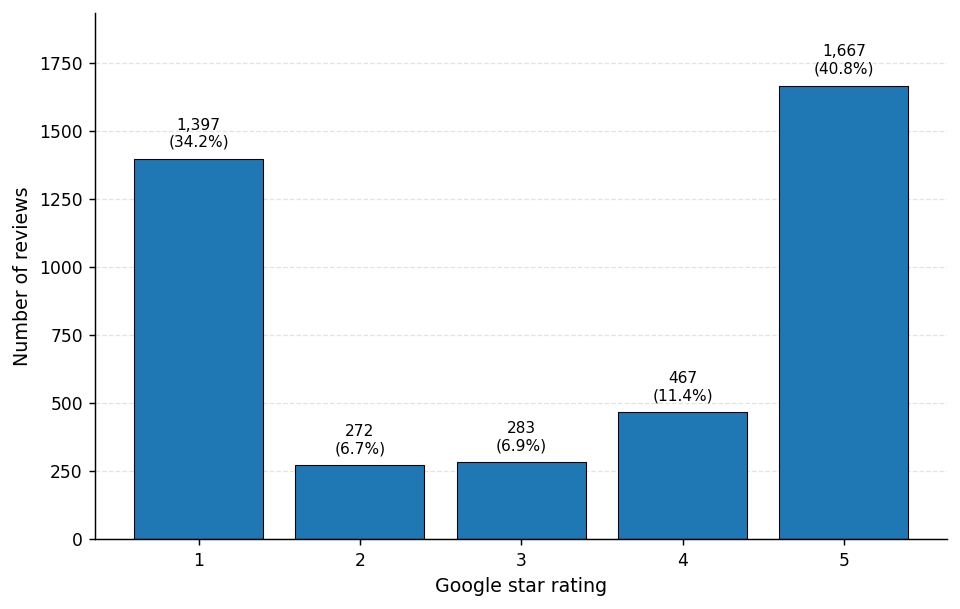

In [4]:
rating_counts = (
    df["review_rating_num"]
    .value_counts()
    .reindex([1,2,3,4,5], fill_value=0)
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    edgecolor="black",
    linewidth=0.6,
)
ax.set_xlabel("Google star rating")
ax.set_ylabel("Number of reviews")
style_axis(ax, "y")

for bar, value in zip(bars, rating_counts.values):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value + rating_counts.max()*0.02,
        f"{value:,}\n({value/len(df):.1%})",
        ha="center", va="bottom", fontsize=8.5,
    )
ax.set_ylim(0, rating_counts.max()*1.16)
fig.tight_layout()
save_figure(fig, "fig01_star_rating_distribution")
plt.show()
plt.close(fig)

rating_counts.rename("n").to_csv(
    TABLE_DIR / "star_rating_distribution.csv",
    encoding="utf-8-sig",
)


## 4. Review length by star rating — Figure 2

Review length is summarized with medians and interquartile ranges because the distribution is strongly right-skewed. This can reveal whether low-rated experiences tend to be described in more detail.


Saved: clinic_mixed_methods_outputs\figures\fig02_review_length_by_star.pdf


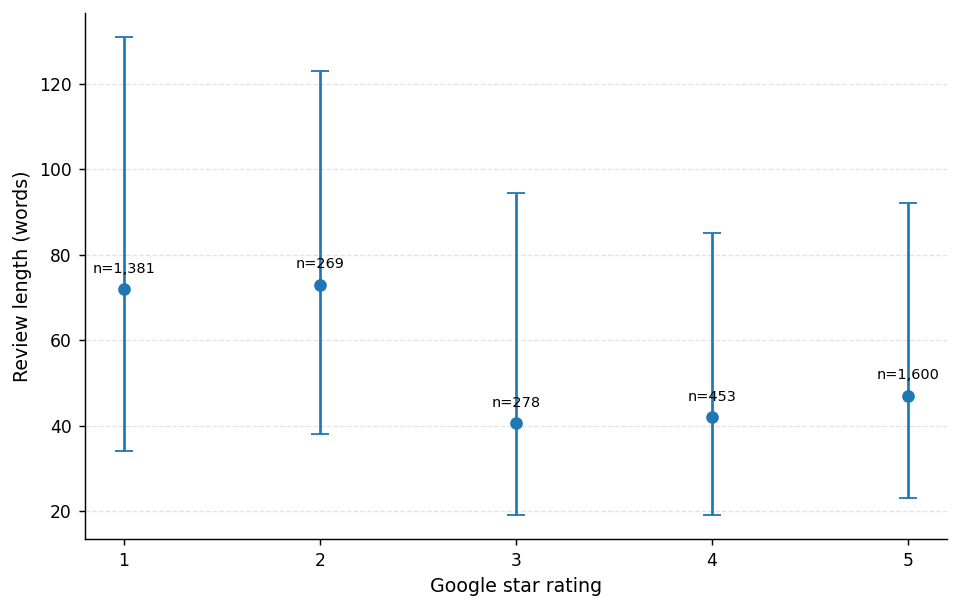

In [5]:
length_by_star = (
    text_df.groupby("review_rating_num")["word_count"]
    .agg(
        n="size",
        median="median",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        mean="mean",
    )
    .reindex([1,2,3,4,5])
)

x = np.arange(5)
med = length_by_star["median"].to_numpy(float)
lower = med - length_by_star["q25"].to_numpy(float)
upper = length_by_star["q75"].to_numpy(float) - med

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(
    x, med, yerr=np.vstack([lower, upper]),
    fmt="o", capsize=5, linewidth=1.5,
)
ax.set_xticks(x)
ax.set_xticklabels([1,2,3,4,5])
ax.set_xlabel("Google star rating")
ax.set_ylabel("Review length (words)")
style_axis(ax, "y")

for xi, yi, n in zip(x, med, length_by_star["n"]):
    ax.annotate(
        f"n={int(n):,}", (xi, yi),
        xytext=(0, 9), textcoords="offset points",
        ha="center", fontsize=8,
    )

fig.tight_layout()
save_figure(fig, "fig02_review_length_by_star")
plt.show()
plt.close(fig)

length_by_star.to_csv(
    TABLE_DIR / "review_length_by_star.csv",
    encoding="utf-8-sig",
)


## 5. Clinic review-volume coverage — Figure 3

This figure is about **coverage**, not clinic quality. It shows how much information is available per clinic and supports the minimum-volume rule used later.


Saved: clinic_mixed_methods_outputs\figures\fig03_clinic_review_coverage.pdf


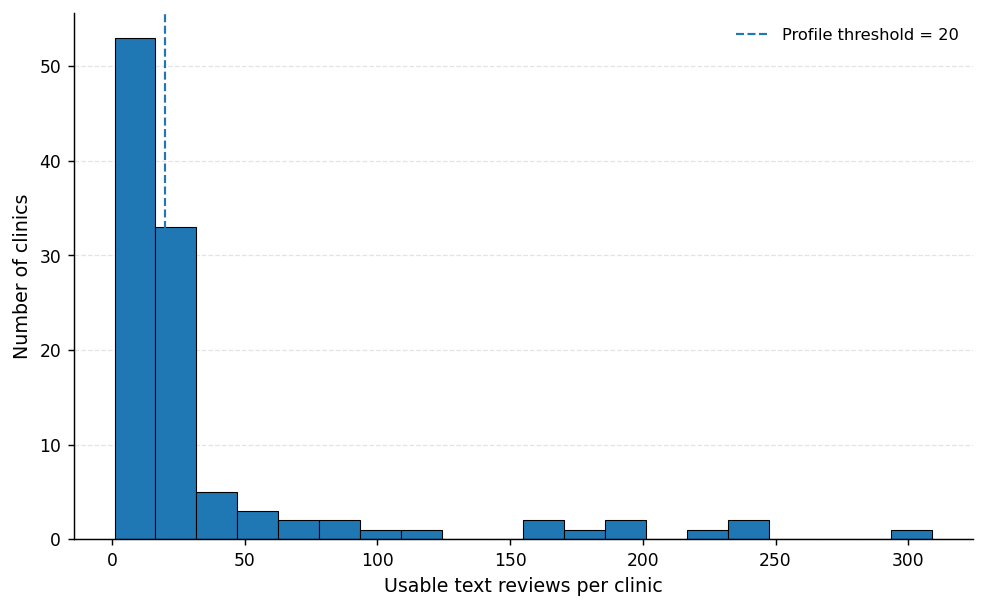

Clinics with at least 20 text reviews: 45


In [6]:
clinic_counts = (
    text_df.groupby("clinic")
    .size()
    .rename("text_reviews")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7.7, 4.8))
ax.hist(
    clinic_counts.values,
    bins=20,
    edgecolor="black",
    linewidth=0.6,
)
ax.axvline(
    MIN_CLINIC_TEXT_REVIEWS,
    linestyle="--",
    linewidth=1.2,
    label=f"Profile threshold = {MIN_CLINIC_TEXT_REVIEWS}",
)
ax.set_xlabel("Usable text reviews per clinic")
ax.set_ylabel("Number of clinics")
ax.legend(frameon=False)
style_axis(ax, "y")
fig.tight_layout()
save_figure(fig, "fig03_clinic_review_coverage")
plt.show()
plt.close(fig)

clinic_counts.to_csv(
    TABLE_DIR / "clinic_text_review_counts.csv",
    encoding="utf-8-sig",
)
print(
    f"Clinics with at least {MIN_CLINIC_TEXT_REVIEWS} text reviews:",
    int((clinic_counts >= MIN_CLINIC_TEXT_REVIEWS).sum()),
)


# Part II — Text sentiment as an independent quantitative signal

Here, the star rating and GPT textual sentiment are compared for **alignment**, not accuracy. The rating is not treated as a gold label.


## 6. GPT sentiment distribution and sentiment within each star group — Figure 4


Saved: clinic_mixed_methods_outputs\figures\fig04_gpt_sentiment_and_star_composition.pdf


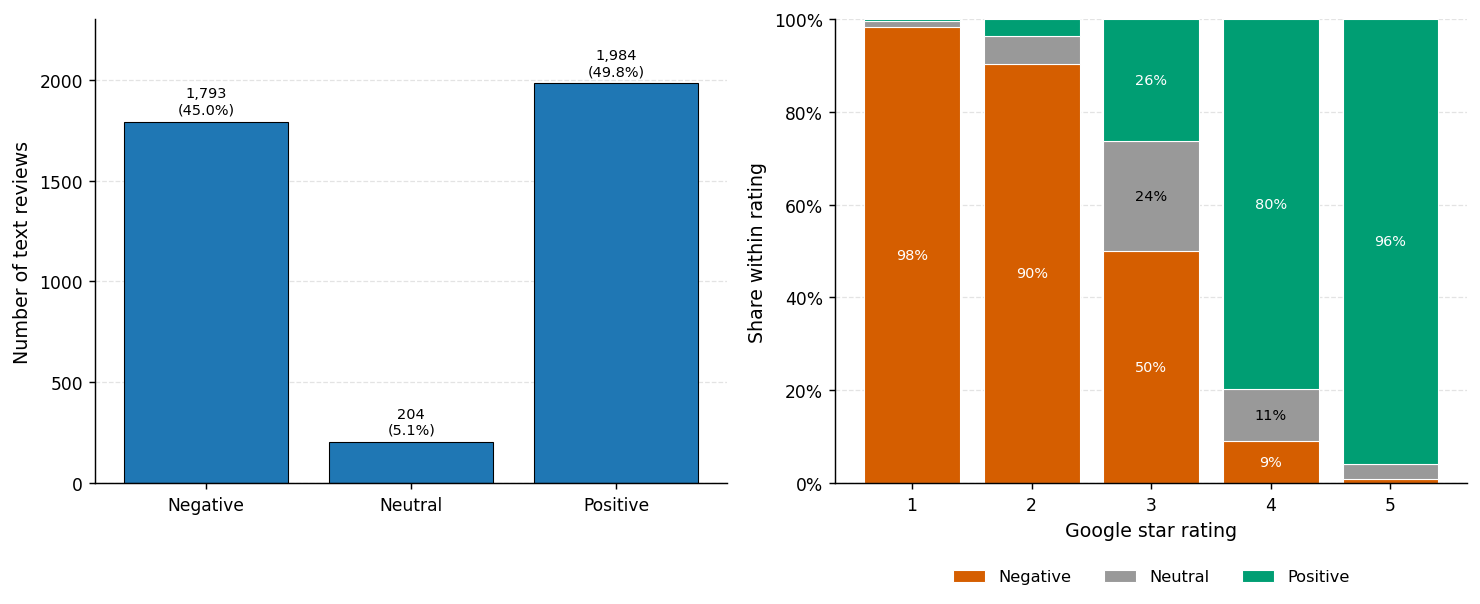

In [7]:
gpt_counts = (
    text_df["gpt_norm"]
    .value_counts()
    .reindex(LABELS, fill_value=0)
)

gpt_by_star = pd.crosstab(
    text_df["review_rating_num"],
    text_df["gpt_norm"],
    normalize="index",
).reindex(
    index=[1,2,3,4,5],
    columns=PLOT_SENTIMENT_ORDER,
    fill_value=0,
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

bars = axes[0].bar(
    [x.capitalize() for x in LABELS],
    gpt_counts.values,
    edgecolor="black",
    linewidth=0.6,
)
axes[0].set_ylabel("Number of text reviews")
style_axis(axes[0], "y")
for bar, value in zip(bars, gpt_counts.values):
    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        value + gpt_counts.max()*0.02,
        f"{value:,}\n({value/len(text_df):.1%})",
        ha="center", fontsize=8,
    )
axes[0].set_ylim(0, gpt_counts.max()*1.16)

draw_100pct_stacked(
    gpt_by_star,
    axes[1],
    xlabel="Google star rating",
)
axes[1].legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.25))

fig.tight_layout()
save_figure(fig, "fig04_gpt_sentiment_and_star_composition")
plt.show()
plt.close(fig)

gpt_by_star.to_csv(
    TABLE_DIR / "gpt_sentiment_by_star.csv",
    encoding="utf-8-sig",
)


## 7. Ordinal association between stars and text sentiment

The sentiment index (`-1, 0, +1`) is an aggregation device. Spearman's rho and Kendall's tau quantify ordinal association; they are **not model-accuracy statistics**.


In [8]:
rho, rho_p = spearmanr(
    text_df["review_rating_num"],
    text_df["gpt_sentiment_index"],
)
tau, tau_p = kendalltau(
    text_df["review_rating_num"],
    text_df["gpt_sentiment_index"],
)

association = pd.DataFrame({
    "measure": ["Spearman rho", "Kendall tau"],
    "estimate": [rho, tau],
    "p_value": [rho_p, tau_p],
    "n": [len(text_df), len(text_df)],
})

display(association.round(4))
association.to_csv(
    TABLE_DIR / "star_gpt_ordinal_association.csv",
    index=False,
    encoding="utf-8-sig",
)


,measure,estimate,p_value,n
0,Spearman rho,0.8899,0.0,3981
1,Kendall tau,0.8207,0.0,3981


## 8. Rating–text alignment and discordant cases — Figure 5

For descriptive alignment only:
- 1–2★ → negative
- 3★ → neutral
- 4–5★ → positive

The resulting agreement rate should be called **rating–text alignment**, never accuracy.


Saved: clinic_mixed_methods_outputs\figures\fig05_rating_text_alignment_by_star.pdf


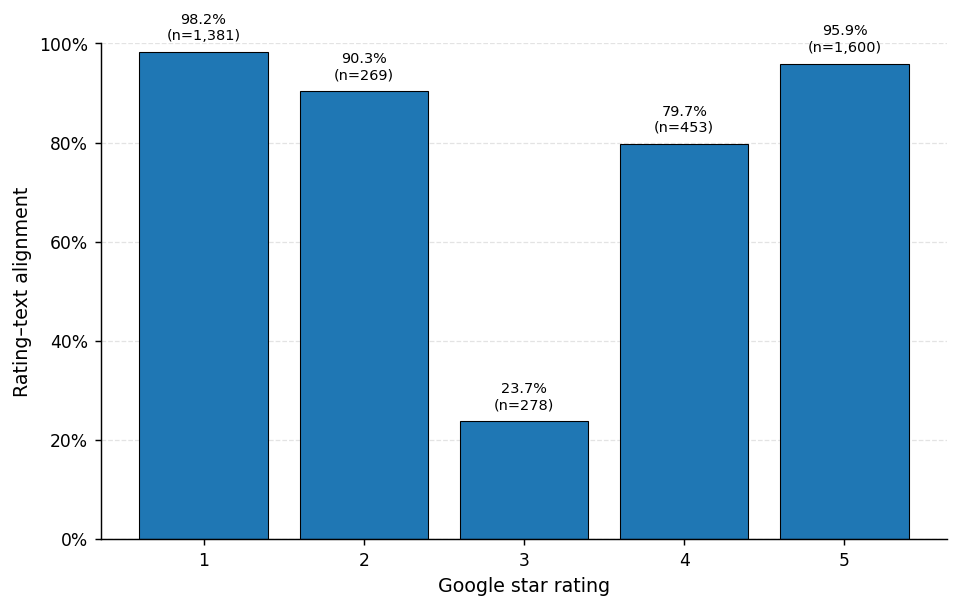

Overall rating–text alignment: 89.4%
Discordant cases: 421


,n
discordance_type,
3-star / negative text,139
Adjacent-category mismatch,138
3-star / positive text,73
High rating / negative text,55
Low rating / positive text,16


In [9]:
text_df["rating_text_aligned"] = (
    text_df["gpt_norm"] == text_df["star_sentiment_heuristic"]
)

alignment_by_star = (
    text_df.groupby("review_rating_num")
    .agg(
        n=("review_id", "size"),
        alignment_rate=("rating_text_aligned", "mean"),
    )
    .reindex([1,2,3,4,5])
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(
    alignment_by_star.index.astype(str),
    alignment_by_star["alignment_rate"],
    edgecolor="black",
    linewidth=0.6,
)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Google star rating")
ax.set_ylabel("Rating–text alignment")
style_axis(ax, "y")

for bar, rate, n in zip(
    bars,
    alignment_by_star["alignment_rate"],
    alignment_by_star["n"],
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        rate + 0.025,
        f"{rate:.1%}\n(n={int(n):,})",
        ha="center", fontsize=8,
    )

fig.tight_layout()
save_figure(fig, "fig05_rating_text_alignment_by_star")
plt.show()
plt.close(fig)

alignment_by_star.to_csv(
    TABLE_DIR / "rating_text_alignment_by_star.csv",
    encoding="utf-8-sig",
)

discordant = text_df.loc[
    ~text_df["rating_text_aligned"],
    [
        "review_id", "clinic", "review_rating_num",
        "gpt_norm", "review_text",
    ],
].copy()

discordant["discordance_type"] = np.select(
    [
        (discordant["review_rating_num"] <= 2) & (discordant["gpt_norm"] == "positive"),
        (discordant["review_rating_num"] >= 4) & (discordant["gpt_norm"] == "negative"),
        (discordant["review_rating_num"] == 3) & (discordant["gpt_norm"] == "positive"),
        (discordant["review_rating_num"] == 3) & (discordant["gpt_norm"] == "negative"),
    ],
    [
        "Low rating / positive text",
        "High rating / negative text",
        "3-star / positive text",
        "3-star / negative text",
    ],
    default="Adjacent-category mismatch",
)

discordant.to_excel(
    CASE_DIR / "rating_text_discordant_cases.xlsx",
    index=False,
)

print("Overall rating–text alignment:", f"{text_df['rating_text_aligned'].mean():.1%}")
print("Discordant cases:", f"{len(discordant):,}")
display(discordant["discordance_type"].value_counts().to_frame("n"))


# Part III — Multi-model robustness, not model competition

The four server models are used to test whether the main rating–sentiment pattern is robust to model choice.

Because there is no human sentiment gold standard:
- **do not rank models by Accuracy/Macro F1**;
- do report pairwise agreement, rating association, and review-level consensus strength.


## 9. Load and validate the four server prediction files


In [10]:
expected_text_ids = set(text_df["review_id"].astype(int))

server_predictions = {}
server_status_rows = []

for model_name, filename in SERVER_MODEL_FILES.items():
    path = SERVER_RESULTS_DIR / filename

    if not path.exists():
        server_status_rows.append({
            "model": model_name,
            "status": "missing",
            "rows": 0,
        })
        continue

    pred = pd.read_csv(path)[["review_id", "prediction"]].copy()
    pred["review_id"] = pd.to_numeric(pred["review_id"], errors="raise").astype(int)
    pred["prediction"] = pred["prediction"].map(normalize_label)

    if pred["review_id"].duplicated().any():
        raise ValueError(f"{model_name}: duplicate review_id.")
    if not pred["prediction"].isin(LABELS).all():
        raise ValueError(f"{model_name}: invalid or missing sentiment label.")

    observed_ids = set(pred["review_id"])
    missing_ids = expected_text_ids - observed_ids
    extra_ids = observed_ids - expected_text_ids

    if len(pred) != EXPECTED_TEXT_REVIEWS or missing_ids or extra_ids:
        raise ValueError(
            f"{model_name}: incomplete full result "
            f"(rows={len(pred):,}, missing={len(missing_ids)}, extra={len(extra_ids)})."
        )

    server_predictions[model_name] = pred
    server_status_rows.append({
        "model": model_name,
        "status": "loaded and validated",
        "rows": len(pred),
    })

server_status = pd.DataFrame(server_status_rows)
display(server_status)

missing_models = server_status.loc[
    server_status["status"] == "missing", "model"
].tolist()

if missing_models:
    print(
        "Server robustness analysis will remain partial until these files are copied:",
        ", ".join(missing_models),
    )


,model,status,rows
0,CardiffNLP RoBERTa,loaded and validated,3981
1,BERTweet,loaded and validated,3981
2,Qwen3.5-9B,loaded and validated,3981
3,Gemma 3 12B IT,loaded and validated,3981


## 10. Build the five-model review-level matrix

GPT-5.6 Sol is the primary model and the four server models are robustness models. When all five are available, every review receives a majority-vote consensus label and an agreement strength from 3/5 to 5/5.


In [11]:
model_matrix = text_df[
    ["review_id", "clinic", "review_rating_num", "gpt_norm", "review_text"]
].rename(columns={"gpt_norm": "GPT-5.6 Sol"}).copy()

for model_name, pred in server_predictions.items():
    model_matrix = model_matrix.merge(
        pred.rename(columns={"prediction": model_name}),
        on="review_id",
        how="left",
        validate="one_to_one",
    )

MODEL_COLUMNS = [
    "GPT-5.6 Sol",
    *[m for m in SERVER_MODEL_FILES if m in server_predictions],
]

for col in MODEL_COLUMNS:
    if not model_matrix[col].isin(LABELS).all():
        raise ValueError(f"Incomplete labels in {col}.")

def majority_label(row):
    counts = Counter(row[MODEL_COLUMNS])
    return counts.most_common(1)[0][0]

def majority_n(row):
    counts = Counter(row[MODEL_COLUMNS])
    return counts.most_common(1)[0][1]

model_matrix["consensus_sentiment"] = model_matrix.apply(majority_label, axis=1)
model_matrix["max_agree_n"] = model_matrix.apply(majority_n, axis=1)
model_matrix["n_models"] = len(MODEL_COLUMNS)
model_matrix["agreement_strength"] = (
    model_matrix["max_agree_n"].astype(str)
    + "/"
    + model_matrix["n_models"].astype(str)
)

model_matrix.to_csv(
    TABLE_DIR / "review_level_model_matrix.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Models available:", MODEL_COLUMNS)
display(model_matrix["agreement_strength"].value_counts().sort_index().to_frame("n"))


Models available: ['GPT-5.6 Sol', 'CardiffNLP RoBERTa', 'BERTweet', 'Qwen3.5-9B', 'Gemma 3 12B IT']


,n
agreement_strength,
2/5,44
3/5,425
4/5,483
5/5,3029


## 11. Pairwise model agreement — Figure 6


Saved: clinic_mixed_methods_outputs\figures\fig06_pairwise_model_kappa.pdf


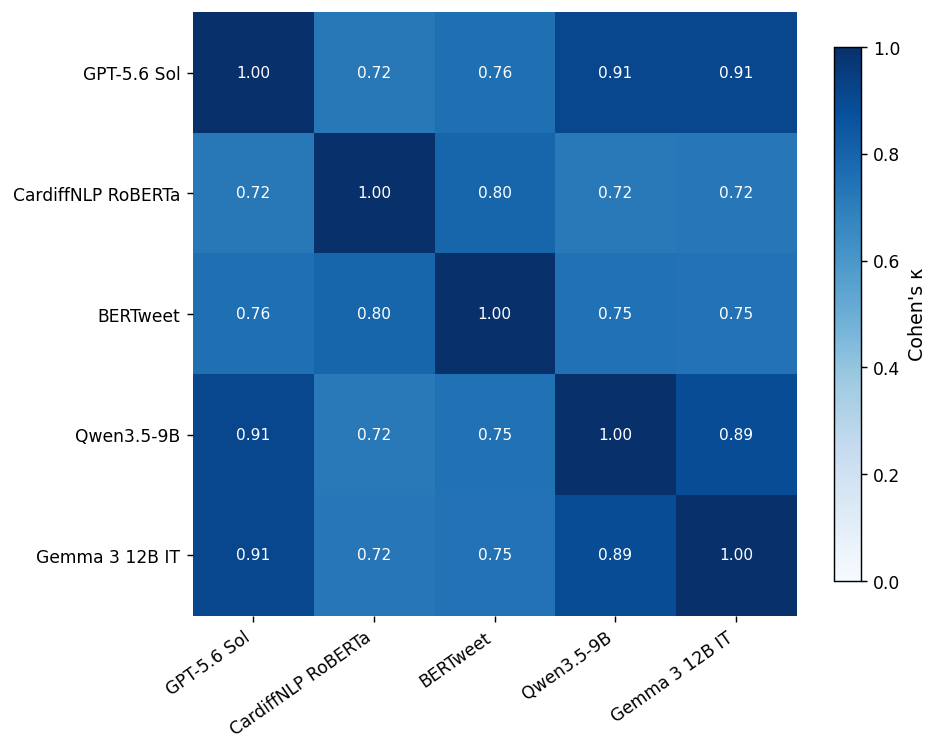

In [12]:
if len(MODEL_COLUMNS) < 2:
    print(
        "Pairwise agreement skipped: fewer than two text models are available. "
        "Copy hpc_clinic_outputs/ and rerun Part III."
    )
    kappa_matrix = pd.DataFrame()
else:
    kappa_matrix = pd.DataFrame(
        np.eye(len(MODEL_COLUMNS)),
        index=MODEL_COLUMNS,
        columns=MODEL_COLUMNS,
    )

    for i, m1 in enumerate(MODEL_COLUMNS):
        for j, m2 in enumerate(MODEL_COLUMNS):
            if i == j:
                continue
            kappa_matrix.loc[m1, m2] = cohen_kappa_score(
                model_matrix[m1],
                model_matrix[m2],
                labels=LABELS,
            )

    fig, ax = plt.subplots(figsize=(7.5, 6.3))
    im = ax.imshow(
        kappa_matrix.to_numpy(float),
        cmap="Blues",
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(range(len(MODEL_COLUMNS)))
    ax.set_yticks(range(len(MODEL_COLUMNS)))
    ax.set_xticklabels(MODEL_COLUMNS, rotation=35, ha="right")
    ax.set_yticklabels(MODEL_COLUMNS)

    matrix = kappa_matrix.to_numpy(float)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            ax.text(
                j, i, f"{value:.2f}",
                ha="center", va="center",
                color="white" if value > 0.55 else "black",
                fontsize=8.5,
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.colorbar(im, ax=ax, label="Cohen's κ", shrink=0.8)
    fig.tight_layout()
    save_figure(fig, "fig06_pairwise_model_kappa")
    plt.show()
    plt.close(fig)

    kappa_matrix.to_csv(
        TABLE_DIR / "pairwise_model_kappa.csv",
        encoding="utf-8-sig",
    )


## 12. Robustness of the star–sentiment relationship across models — Figure 7

Instead of asking “which model is best?”, this figure asks whether all models tell the same substantive story across the five rating groups.


,model,spearman_rho,p_value,n
0,GPT-5.6 Sol,0.8899,0.0,3981
1,CardiffNLP RoBERTa,0.8111,0.0,3981
2,BERTweet,0.8303,0.0,3981
3,Qwen3.5-9B,0.8882,0.0,3981
4,Gemma 3 12B IT,0.8864,0.0,3981


Saved: clinic_mixed_methods_outputs\figures\fig07_model_robustness_by_star.pdf


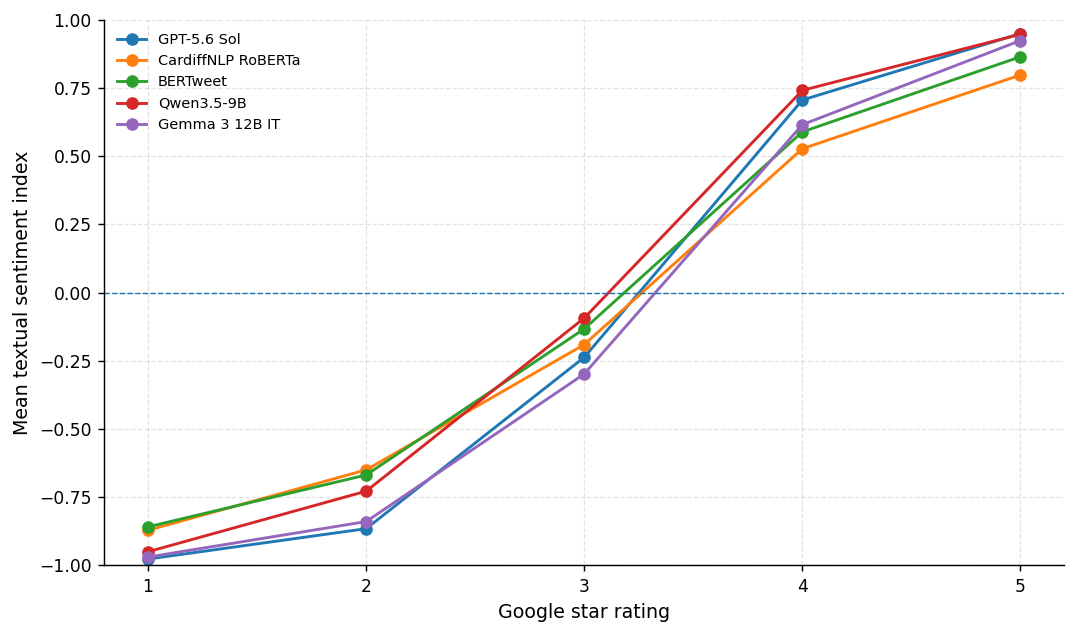

In [13]:
model_star_rows = []

for model_name in MODEL_COLUMNS:
    tmp = model_matrix[["review_rating_num", model_name]].copy()
    tmp["sentiment_index"] = tmp[model_name].map(INDEX_MAP)

    rho, p = spearmanr(
        tmp["review_rating_num"],
        tmp["sentiment_index"],
    )

    model_star_rows.append({
        "model": model_name,
        "spearman_rho": rho,
        "p_value": p,
        "n": len(tmp),
    })

model_star_association = pd.DataFrame(model_star_rows)
display(model_star_association.round(4))
model_star_association.to_csv(
    TABLE_DIR / "model_star_association.csv",
    index=False,
    encoding="utf-8-sig",
)

mean_index_by_star = {}

for model_name in MODEL_COLUMNS:
    vals = model_matrix.assign(
        sentiment_index=model_matrix[model_name].map(INDEX_MAP)
    ).groupby("review_rating_num")["sentiment_index"].mean()
    mean_index_by_star[model_name] = vals

mean_index_by_star = pd.DataFrame(mean_index_by_star).reindex([1,2,3,4,5])

fig, ax = plt.subplots(figsize=(8.4, 5.0))
for model_name in MODEL_COLUMNS:
    ax.plot(
        mean_index_by_star.index,
        mean_index_by_star[model_name],
        marker="o",
        label=model_name,
    )

ax.axhline(0, linewidth=0.8, linestyle="--")
ax.set_xticks([1,2,3,4,5])
ax.set_ylim(-1, 1)
ax.set_xlabel("Google star rating")
ax.set_ylabel("Mean textual sentiment index")
ax.legend(frameon=False, fontsize=8)
style_axis(ax, "both")
fig.tight_layout()
save_figure(fig, "fig07_model_robustness_by_star")
plt.show()
plt.close(fig)

mean_index_by_star.to_csv(
    TABLE_DIR / "mean_sentiment_index_by_star_and_model.csv",
    encoding="utf-8-sig",
)


## 13. Model consensus strength — Figure 8 and case export

Low-consensus reviews are analytically valuable because they are linguistically ambiguous or mixed. They are exported for targeted qualitative inspection rather than discarded.


Saved: clinic_mixed_methods_outputs\figures\fig08_model_consensus_strength.pdf


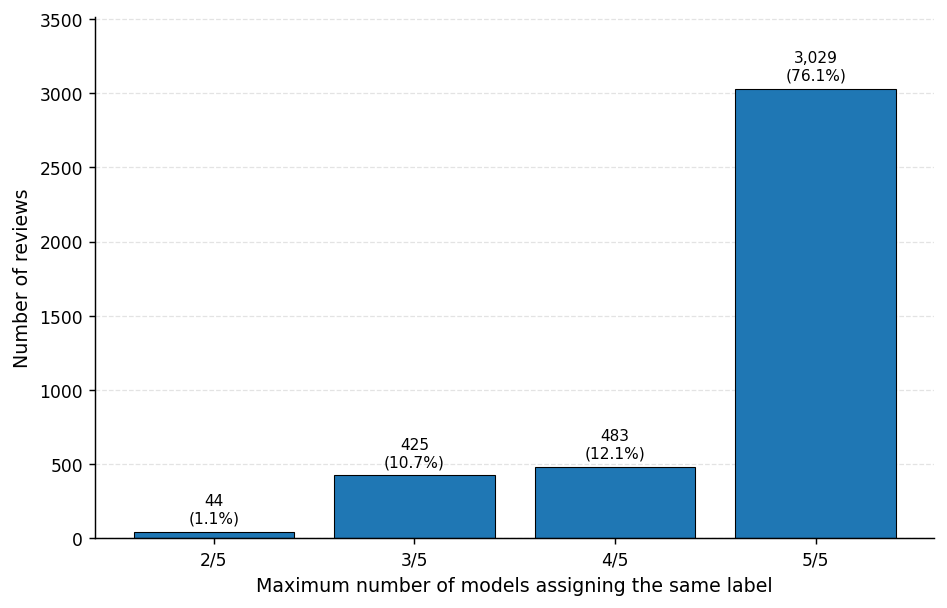

Lowest observed consensus: 2/5; cases exported: 44


In [14]:
if len(MODEL_COLUMNS) < 3:
    print(
        "Consensus-strength analysis skipped: at least three models are needed "
        "for a meaningful majority-vote robustness analysis."
    )
    low_consensus = pd.DataFrame()
else:
    agreement_counts = (
        model_matrix["agreement_strength"]
        .value_counts()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    bars = ax.bar(
        agreement_counts.index,
        agreement_counts.values,
        edgecolor="black",
        linewidth=0.6,
    )
    ax.set_xlabel("Maximum number of models assigning the same label")
    ax.set_ylabel("Number of reviews")
    style_axis(ax, "y")

    for bar, value in zip(bars, agreement_counts.values):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            value + agreement_counts.max()*0.02,
            f"{value:,}\n({value/len(model_matrix):.1%})",
            ha="center", fontsize=8.5,
        )
    ax.set_ylim(0, agreement_counts.max()*1.16)

    fig.tight_layout()
    save_figure(fig, "fig08_model_consensus_strength")
    plt.show()
    plt.close(fig)

    # Lowest-consensus cases: useful for MAXQDA/QTT interpretive follow-up.
    min_agree = model_matrix["max_agree_n"].min()
    low_consensus = model_matrix.loc[
        model_matrix["max_agree_n"] == min_agree
    ].copy()

    low_consensus.to_excel(
        CASE_DIR / "lowest_model_consensus_cases.xlsx",
        index=False,
    )

    print(
        f"Lowest observed consensus: {min_agree}/{len(MODEL_COLUMNS)}; "
        f"cases exported: {len(low_consensus):,}"
    )


# Part IV — Clinic-level heterogeneity without “best/worst” rankings

The purpose is to identify **variation and rating–text divergence**, not to publish league tables of healthcare providers.

Only clinics with at least 20 usable text reviews are profiled.


## 14. Clinic-level rating vs textual sentiment — Figure 9


Saved: clinic_mixed_methods_outputs\figures\fig09_clinic_rating_text_heterogeneity.pdf


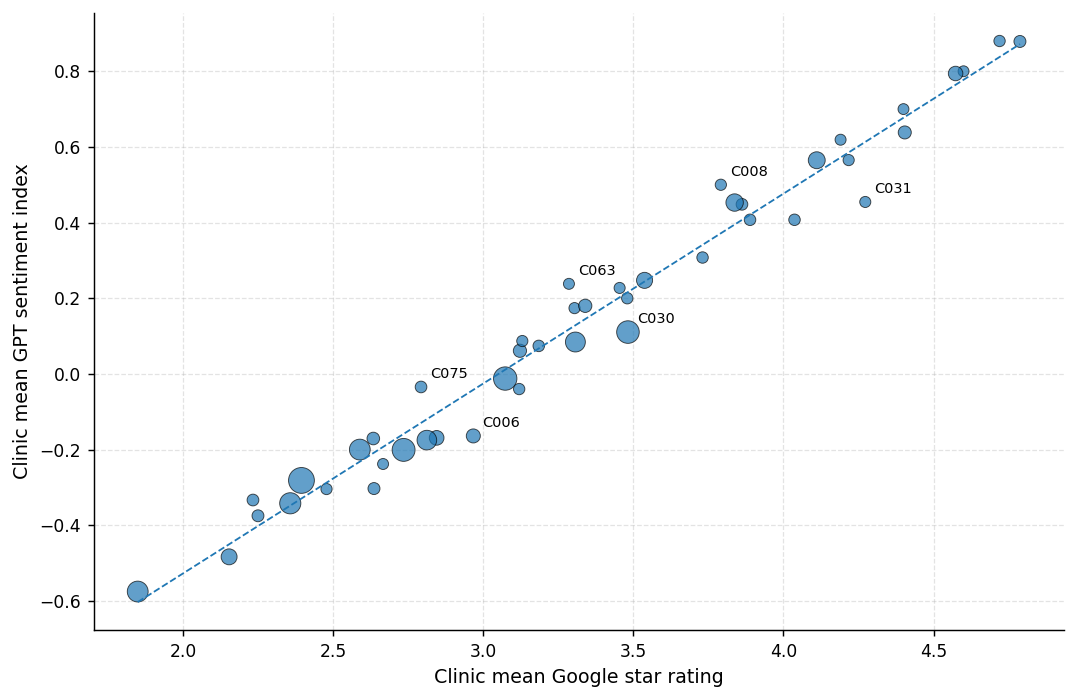

Eligible clinics: 45
Figure labels use anonymized clinic codes; the exported profile table retains the clinic-name mapping.


In [15]:
# Stable anonymized clinic codes for figures; full names remain in the exported table.
clinic_names = sorted(text_df["clinic"].astype(str).unique())
clinic_code_map = {
    name: f"C{i:03d}"
    for i, name in enumerate(clinic_names, start=1)
}

clinic_profile = (
    text_df.groupby("clinic")
    .agg(
        n=("review_id", "size"),
        mean_star=("review_rating_num", "mean"),
        gpt_sentiment_index=("gpt_sentiment_index", "mean"),
        negative_share=("gpt_norm", lambda s: (s == "negative").mean()),
        neutral_share=("gpt_norm", lambda s: (s == "neutral").mean()),
        positive_share=("gpt_norm", lambda s: (s == "positive").mean()),
    )
    .reset_index()
)
clinic_profile["clinic_code"] = clinic_profile["clinic"].map(clinic_code_map)

eligible_clinics = clinic_profile.loc[
    clinic_profile["n"] >= MIN_CLINIC_TEXT_REVIEWS
].copy()

# Residual from a simple linear fit identifies rating–text divergence.
# It is descriptive and is not interpreted as clinic quality.
coef = np.polyfit(
    eligible_clinics["mean_star"],
    eligible_clinics["gpt_sentiment_index"],
    deg=1,
)
eligible_clinics["expected_text_index"] = np.polyval(
    coef,
    eligible_clinics["mean_star"],
)
eligible_clinics["rating_text_residual"] = (
    eligible_clinics["gpt_sentiment_index"]
    - eligible_clinics["expected_text_index"]
)

eligible_clinics.to_csv(
    TABLE_DIR / "clinic_rating_text_profiles.csv",
    index=False,
    encoding="utf-8-sig",
)

fig, ax = plt.subplots(figsize=(8.4, 5.5))

sizes = 25 + 180 * (
    eligible_clinics["n"] / eligible_clinics["n"].max()
)

ax.scatter(
    eligible_clinics["mean_star"],
    eligible_clinics["gpt_sentiment_index"],
    s=sizes,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
)

xline = np.linspace(
    eligible_clinics["mean_star"].min(),
    eligible_clinics["mean_star"].max(),
    100,
)
ax.plot(xline, np.polyval(coef, xline), linestyle="--", linewidth=1)

# Label only the six largest divergences, using anonymous clinic codes.
label_df = (
    eligible_clinics.assign(
        abs_residual=eligible_clinics["rating_text_residual"].abs()
    )
    .nlargest(6, "abs_residual")
)

for _, row in label_df.iterrows():
    ax.annotate(
        row["clinic_code"],
        (row["mean_star"], row["gpt_sentiment_index"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Clinic mean Google star rating")
ax.set_ylabel("Clinic mean GPT sentiment index")
style_axis(ax, "both")

fig.tight_layout()
save_figure(fig, "fig09_clinic_rating_text_heterogeneity")
plt.show()
plt.close(fig)

print("Eligible clinics:", len(eligible_clinics))
print(
    "Figure labels use anonymized clinic codes; "
    "the exported profile table retains the clinic-name mapping."
)


# Part V — MAXQDA qualitative integration

## Required MAXQDA bridge file

After the student completes the qualitative coding, export or construct a **long-format** CSV named:

`maxqda_review_codes.csv`

Minimum columns:

```text
review_id,code
```

Optional:

```text
code_group
```

A review may appear on multiple rows because qualitative coding is multi-label.

### Recommended qualitative procedure
- Reviews may be worked through by 1★, 2★, 3★, 4★, and 5★ strata as planned.
- Maintain a **single progressively consolidated master codebook** across all strata.
- Keep the coder blind to GPT/server sentiment labels during coding.
- Use MAXQDA QTT for representative quotations, memos, and visual summaries.
- Integrate QUAN and QUAL only after both strands are complete.


## 15. Export a linkage key for MAXQDA/research audit


In [16]:
linkage_key = df[
    ["review_id", "clinic", "review_rating_num", "review_text"]
].copy()

linkage_key.to_excel(
    TABLE_DIR / "maxqda_linkage_key.xlsx",
    index=False,
)

print("Saved:", TABLE_DIR / "maxqda_linkage_key.xlsx")


Saved: clinic_mixed_methods_outputs\tables\maxqda_linkage_key.xlsx


## 16. Load MAXQDA codes and create the star × theme joint display — Figure 10

This cell safely skips until `maxqda_review_codes.csv` is available.


In [17]:
maxqda_available = MAXQDA_CODES_FILE.exists()
print("MAXQDA code file available:", maxqda_available)

if maxqda_available:
    codes = pd.read_csv(MAXQDA_CODES_FILE).copy()

    required = {"review_id", "code"}
    missing = required - set(codes.columns)
    if missing:
        raise ValueError(
            f"MAXQDA bridge file is missing columns: {sorted(missing)}"
        )

    codes["review_id"] = pd.to_numeric(
        codes["review_id"], errors="raise"
    ).astype(int)
    codes["code"] = codes["code"].astype(str).str.strip()

    # Quantitative integration is restricted to reviews that actually contain text.
    codes = codes[
        codes["code"].ne("")
        & codes["review_id"].isin(expected_text_ids)
    ].drop_duplicates(["review_id", "code"])

    coded_reviews = (
        codes[["review_id"]]
        .drop_duplicates()
        .merge(
            text_df[
                ["review_id", "review_rating_num", "gpt_norm"]
            ],
            on="review_id",
            how="left",
            validate="one_to_one",
        )
    )

    code_review = codes.merge(
        text_df[
            ["review_id", "review_rating_num", "gpt_norm"]
        ],
        on="review_id",
        how="left",
        validate="many_to_one",
    )

    star_denominator = (
        coded_reviews.groupby("review_rating_num")["review_id"]
        .nunique()
        .reindex([1,2,3,4,5])
    )

    code_star_counts = (
        code_review.groupby(["code", "review_rating_num"])["review_id"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1,2,3,4,5], fill_value=0)
    )

    code_star_prev = code_star_counts.div(
        star_denominator,
        axis=1,
    )

    top_codes = (
        code_review.groupby("code")["review_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(15)
        .index
    )
    heat = code_star_prev.loc[top_codes]

    fig, ax = plt.subplots(
        figsize=(8.2, max(5.2, 0.38*len(heat)+1.5))
    )
    im = ax.imshow(
        heat.to_numpy(float),
        cmap="Blues",
        vmin=0,
        vmax=max(0.01, float(np.nanmax(heat.to_numpy(float)))),
        aspect="auto",
    )

    ax.set_xticks(range(5))
    ax.set_xticklabels(["1★", "2★", "3★", "4★", "5★"])
    ax.set_yticks(range(len(heat)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel("Google star rating")
    ax.set_ylabel("MAXQDA theme")

    matrix = heat.to_numpy(float)
    threshold = np.nanmax(matrix) * 0.55 if matrix.size else 0

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            ax.text(
                j, i, f"{value:.0%}",
                ha="center", va="center",
                fontsize=7.5,
                color="white" if value > threshold else "black",
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.colorbar(
        im,
        ax=ax,
        label="Share of coded reviews in star group",
        shrink=0.8,
    )
    fig.tight_layout()
    save_figure(fig, "fig10_maxqda_theme_by_star")
    plt.show()
    plt.close(fig)

    code_star_prev.to_csv(
        TABLE_DIR / "maxqda_theme_prevalence_by_star.csv",
        encoding="utf-8-sig",
    )
else:
    print(
        "Skipped. After MAXQDA coding, place maxqda_review_codes.csv "
        "beside this notebook and rerun Part V."
    )


MAXQDA code file available: False
Skipped. After MAXQDA coding, place maxqda_review_codes.csv beside this notebook and rerun Part V.


## 17. Mixed-methods joint display: themes × ratings × GPT sentiment

This table is the main integration output. It does not replace MAXQDA interpretation; it places the qualitative themes beside independent quantitative signals.


In [18]:
if maxqda_available:
    theme_rows = []

    for code_name, sub in code_review.groupby("code"):
        unique_reviews = sub.drop_duplicates("review_id")
        n = len(unique_reviews)

        theme_rows.append({
            "theme": code_name,
            "coded_reviews": n,
            "mean_star": unique_reviews["review_rating_num"].mean(),
            "one_two_star_share": (
                unique_reviews["review_rating_num"].le(2).mean()
            ),
            "three_star_share": (
                unique_reviews["review_rating_num"].eq(3).mean()
            ),
            "four_five_star_share": (
                unique_reviews["review_rating_num"].ge(4).mean()
            ),
            "gpt_negative_share": (
                unique_reviews["gpt_norm"].eq("negative").mean()
            ),
            "gpt_neutral_share": (
                unique_reviews["gpt_norm"].eq("neutral").mean()
            ),
            "gpt_positive_share": (
                unique_reviews["gpt_norm"].eq("positive").mean()
            ),
        })

    joint_display = (
        pd.DataFrame(theme_rows)
        .sort_values(
            ["coded_reviews", "mean_star"],
            ascending=[False, True],
        )
    )

    # If all five models are available, append consensus-related diagnostics.
    if len(MODEL_COLUMNS) >= 3:
        consensus_map = model_matrix[
            ["review_id", "consensus_sentiment", "max_agree_n", "n_models"]
        ]
        code_consensus = code_review[
            ["review_id", "code"]
        ].drop_duplicates().merge(
            consensus_map,
            on="review_id",
            how="left",
            validate="many_to_one",
        )

        consensus_stats = (
            code_consensus.groupby("code")
            .agg(
                model_consensus_strength=("max_agree_n", "mean"),
                unanimous_or_near_share=(
                    "max_agree_n",
                    lambda s: (
                        s >= max(2, len(MODEL_COLUMNS)-1)
                    ).mean(),
                ),
            )
            .reset_index()
            .rename(columns={"code": "theme"})
        )

        joint_display = joint_display.merge(
            consensus_stats,
            on="theme",
            how="left",
            validate="one_to_one",
        )

    joint_display.to_csv(
        TABLE_DIR / "mixed_methods_joint_display.csv",
        index=False,
        encoding="utf-8-sig",
    )

    display(joint_display.head(20).round(3))
    print(
        "Saved:",
        TABLE_DIR / "mixed_methods_joint_display.csv",
    )
else:
    print("Skipped until MAXQDA codes are available.")


Skipped until MAXQDA codes are available.


## 18. Purposeful case exports for integration

The goal is to help the student use QTT to explain **why** quantitative signals converge or diverge.

Recommended case families:
1. low rating but positive text;
2. high rating but negative text;
3. 3-star reviews with clearly polarized text;
4. lowest multi-model consensus;
5. clinic-level rating–text outliers.

These are not errors to delete. They are analytically informative mixed-methods cases.


In [19]:
# 1–3: rating–text divergence is always available.
discordant.to_excel(
    CASE_DIR / "integration_rating_text_discordance.xlsx",
    index=False,
)

# 4: model ambiguity, only when a multi-model majority is available.
if not low_consensus.empty:
    low_consensus.to_excel(
        CASE_DIR / "integration_low_model_consensus.xlsx",
        index=False,
    )

# 5: clinic-level divergence.
clinic_outlier_names = set(label_df["clinic"].astype(str))

clinic_outlier_cases = text_df.loc[
    text_df["clinic"].astype(str).isin(clinic_outlier_names),
    [
        "review_id", "clinic", "review_rating_num",
        "gpt_norm", "review_text",
    ],
].copy()

clinic_outlier_cases.to_excel(
    CASE_DIR / "integration_clinic_divergence_cases.xlsx",
    index=False,
)

print("Mixed-methods case exports:")
for p in sorted(CASE_DIR.glob("*.xlsx")):
    print(" ", p)


Mixed-methods case exports:
  clinic_mixed_methods_outputs\case_exports\integration_clinic_divergence_cases.xlsx
  clinic_mixed_methods_outputs\case_exports\integration_low_model_consensus.xlsx
  clinic_mixed_methods_outputs\case_exports\integration_rating_text_discordance.xlsx
  clinic_mixed_methods_outputs\case_exports\lowest_model_consensus_cases.xlsx
  clinic_mixed_methods_outputs\case_exports\rating_text_discordant_cases.xlsx


# Part VI — Expanded publication figure library

The figures below deepen the quantitative and mixed-methods interpretation. They are intentionally complementary rather than replacements for Figures 1–10. All are title-free, saved as PDF at 300 DPI with a tight bounding box.


## 19. Additional effect-size and model-ambiguity measures


In [20]:
def annotated_heatmap(
    matrix_df,
    ax,
    cmap="Blues",
    fmt=".0%",
    vmin=None,
    vmax=None,
    cbar_label=None,
    text_threshold=None,
):
    arr = matrix_df.to_numpy(float)

    if vmin is None:
        vmin = float(np.nanmin(arr))
    if vmax is None:
        vmax = float(np.nanmax(arr))

    im = ax.imshow(
        arr,
        cmap=cmap,
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(matrix_df.shape[1]))
    ax.set_xticklabels(matrix_df.columns)
    ax.set_yticks(np.arange(matrix_df.shape[0]))
    ax.set_yticklabels(matrix_df.index)

    if text_threshold is None:
        text_threshold = (
            vmin + 0.55 * (vmax - vmin)
            if vmax > vmin
            else vmax
        )

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            value = arr[i, j]
            ax.text(
                j,
                i,
                format(value, fmt),
                ha="center",
                va="center",
                fontsize=8.2,
                color="white" if value > text_threshold else "black",
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = ax.figure.colorbar(im, ax=ax, shrink=0.82)
    if cbar_label:
        cbar.set_label(cbar_label)

    return im


def cramers_v(table):
    table = np.asarray(table)
    chi2, p_value, _, _ = chi2_contingency(table)

    n = table.sum()
    r, k = table.shape
    phi2 = chi2 / n

    # Bias-corrected Cramér's V.
    phi2_corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1),
    )
    r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)

    denom = min(r_corr - 1, k_corr - 1)
    v = np.sqrt(phi2_corr / denom) if denom > 0 else np.nan

    return chi2, p_value, v


# Add review-level ambiguity measures if not already present.
def normalized_vote_entropy(row):
    counts = Counter(row[MODEL_COLUMNS])
    probs = np.array(list(counts.values()), dtype=float) / len(MODEL_COLUMNS)

    if len(MODEL_COLUMNS) <= 1:
        return 0.0

    entropy = -(probs * np.log(probs)).sum()
    return float(entropy / np.log(len(MODEL_COLUMNS)))


if "vote_entropy_norm" not in model_matrix.columns:
    model_matrix["n_distinct_labels"] = model_matrix[
        MODEL_COLUMNS
    ].nunique(axis=1)

    model_matrix["unanimous"] = (
        model_matrix["max_agree_n"] == len(MODEL_COLUMNS)
    )

    model_matrix["vote_entropy_norm"] = model_matrix.apply(
        normalized_vote_entropy,
        axis=1,
    )

model_matrix["consensus_index"] = (
    model_matrix["consensus_sentiment"].map(INDEX_MAP)
)

contingency = pd.crosstab(
    text_df["review_rating_num"],
    text_df["gpt_norm"],
).reindex(
    index=[1, 2, 3, 4, 5],
    columns=LABELS,
    fill_value=0,
)

chi2, chi2_p, cramer_v = cramers_v(contingency)

association_extended = association.copy()
association_extended = pd.concat(
    [
        association_extended,
        pd.DataFrame([{
            "measure": "Cramer's V",
            "estimate": cramer_v,
            "p_value": chi2_p,
            "n": len(text_df),
        }]),
    ],
    ignore_index=True,
)

display(association_extended.round(4))
association_extended.to_csv(
    TABLE_DIR / "star_gpt_association_extended.csv",
    index=False,
    encoding="utf-8-sig",
)


,measure,estimate,p_value,n
0,Spearman rho,0.8899,0.0,3981
1,Kendall tau,0.8207,0.0,3981
2,Cramer's V,0.6781,0.0,3981


## 20. Rating × GPT sentiment heatmap — Figure 11


Saved: clinic_mixed_methods_outputs\figures\fig11_rating_gpt_sentiment_heatmap.pdf


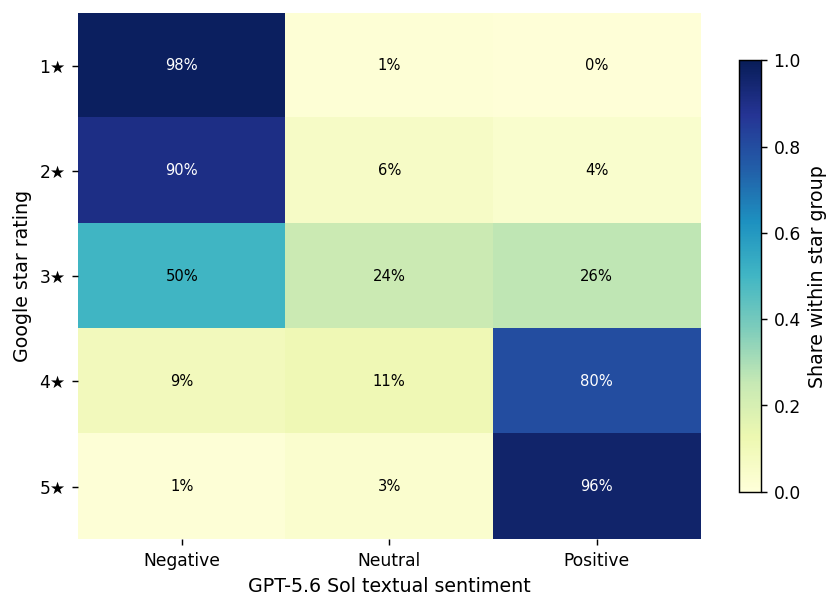

In [21]:
heat = gpt_by_star.copy()
heat.index = [f"{int(x)}★" for x in heat.index]
heat.columns = [x.capitalize() for x in heat.columns]

fig, ax = plt.subplots(figsize=(6.8, 4.8))

annotated_heatmap(
    heat,
    ax,
    cmap="YlGnBu",
    fmt=".0%",
    vmin=0,
    vmax=1,
    cbar_label="Share within star group",
    text_threshold=0.55,
)

ax.set_xlabel("GPT-5.6 Sol textual sentiment")
ax.set_ylabel("Google star rating")

fig.tight_layout()
save_figure(fig, "fig11_rating_gpt_sentiment_heatmap")
plt.show()
plt.close(fig)


## 21. Empirical CDF of clinic review volume — Figure 12


Saved: clinic_mixed_methods_outputs\figures\fig12_clinic_review_volume_ecdf.pdf


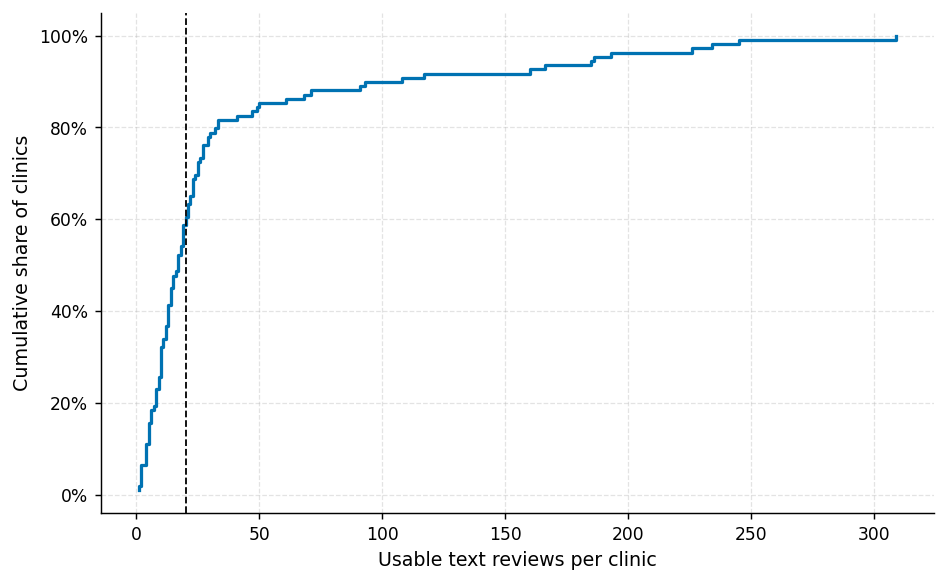

In [22]:
x = np.sort(clinic_counts.to_numpy())
y = np.arange(1, len(x) + 1) / len(x)

fig, ax = plt.subplots(figsize=(7.4, 4.6))

ax.step(
    x,
    y,
    where="post",
    color="#0072B2",
    linewidth=1.8,
)

ax.axvline(
    MIN_CLINIC_TEXT_REVIEWS,
    color="black",
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel("Usable text reviews per clinic")
ax.set_ylabel("Cumulative share of clinics")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
style_axis(ax, "both")

fig.tight_layout()
save_figure(fig, "fig12_clinic_review_volume_ecdf")
plt.show()
plt.close(fig)


## 22. Availability of usable text by star rating — Figure 13


Saved: clinic_mixed_methods_outputs\figures\fig13_text_availability_by_star.pdf


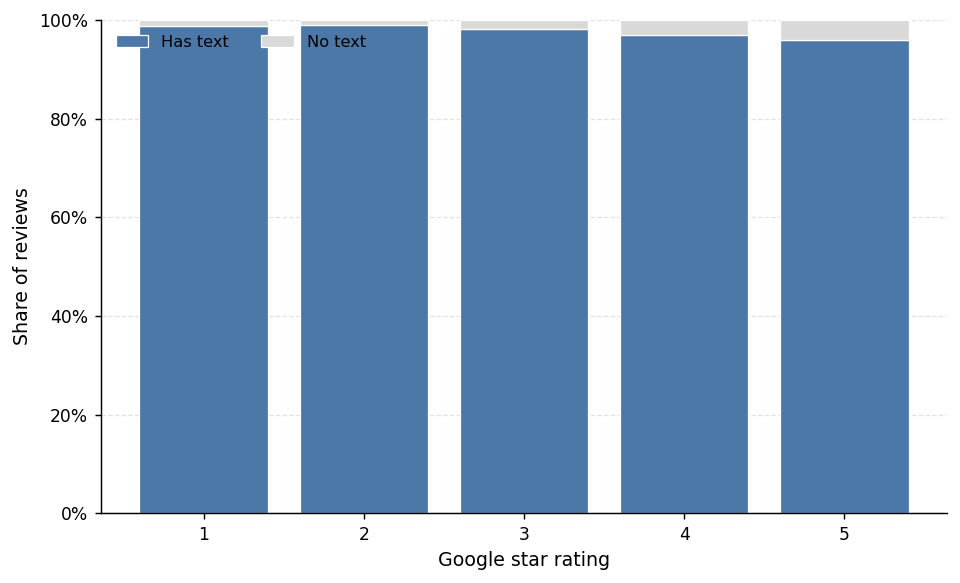

In [23]:
text_availability = (
    pd.crosstab(
        df["review_rating_num"],
        df["has_text"],
        normalize="index",
    )
    .reindex(index=[1, 2, 3, 4, 5], fill_value=0)
    .reindex(columns=[True, False], fill_value=0)
)

text_availability.columns = ["Has text", "No text"]

fig, ax = plt.subplots(figsize=(7.5, 4.6))

bottom = np.zeros(5)
colors = {
    "Has text": "#4C78A8",
    "No text": "#D9D9D9",
}

for col in ["Has text", "No text"]:
    vals = text_availability[col].to_numpy(float)

    ax.bar(
        np.arange(1, 6),
        vals,
        bottom=bottom,
        label=col,
        color=colors[col],
        edgecolor="white",
        linewidth=0.7,
    )

    bottom += vals

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(0, 1)
ax.set_xlabel("Google star rating")
ax.set_ylabel("Share of reviews")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False, ncol=2)
style_axis(ax, "y")

fig.tight_layout()
save_figure(fig, "fig13_text_availability_by_star")
plt.show()
plt.close(fig)

text_availability.to_csv(
    TABLE_DIR / "text_availability_by_star.csv",
    encoding="utf-8-sig",
)


## 23. Sentiment prevalence across all five models — Figure 14


Saved: clinic_mixed_methods_outputs\figures\fig14_model_sentiment_prevalence.pdf


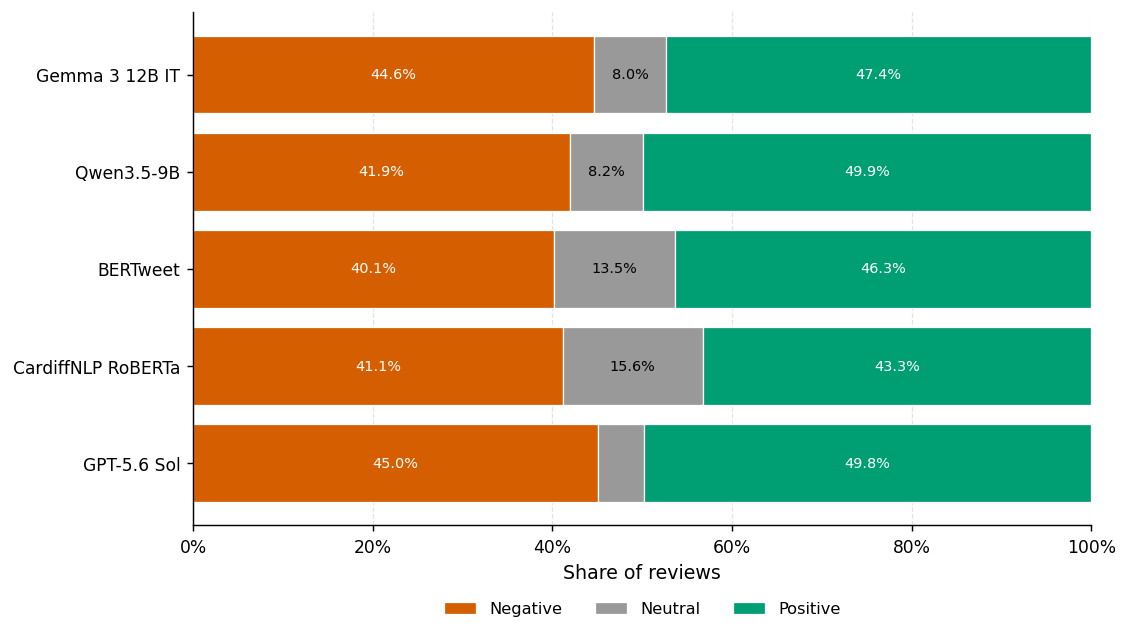

In [24]:
model_sentiment_distribution = pd.DataFrame({
    model: (
        model_matrix[model]
        .value_counts(normalize=True)
        .reindex(LABELS, fill_value=0)
    )
    for model in MODEL_COLUMNS
}).T

fig, ax = plt.subplots(figsize=(8.8, 5.0))

left = np.zeros(len(model_sentiment_distribution))

for label in LABELS:
    vals = model_sentiment_distribution[label].to_numpy(float)

    ax.barh(
        np.arange(len(model_sentiment_distribution)),
        vals,
        left=left,
        color=SENTIMENT_COLORS[label],
        label=label.capitalize(),
        edgecolor="white",
        linewidth=0.7,
    )

    for i, (start, value) in enumerate(zip(left, vals)):
        if value >= 0.075:
            ax.text(
                start + value / 2,
                i,
                f"{value:.1%}",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if label in {"negative", "positive"}
                    else "black"
                ),
            )

    left += vals

ax.set_yticks(np.arange(len(model_sentiment_distribution)))
ax.set_yticklabels(model_sentiment_distribution.index)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Share of reviews")
ax.set_ylabel("")
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
)
style_axis(ax, "x")

fig.tight_layout()
save_figure(fig, "fig14_model_sentiment_prevalence")
plt.show()
plt.close(fig)

model_sentiment_distribution.to_csv(
    TABLE_DIR / "model_sentiment_prevalence.csv",
    encoding="utf-8-sig",
)


## 24. Pairwise raw model agreement — Figure 15


Saved: clinic_mixed_methods_outputs\figures\fig15_pairwise_model_raw_agreement.pdf


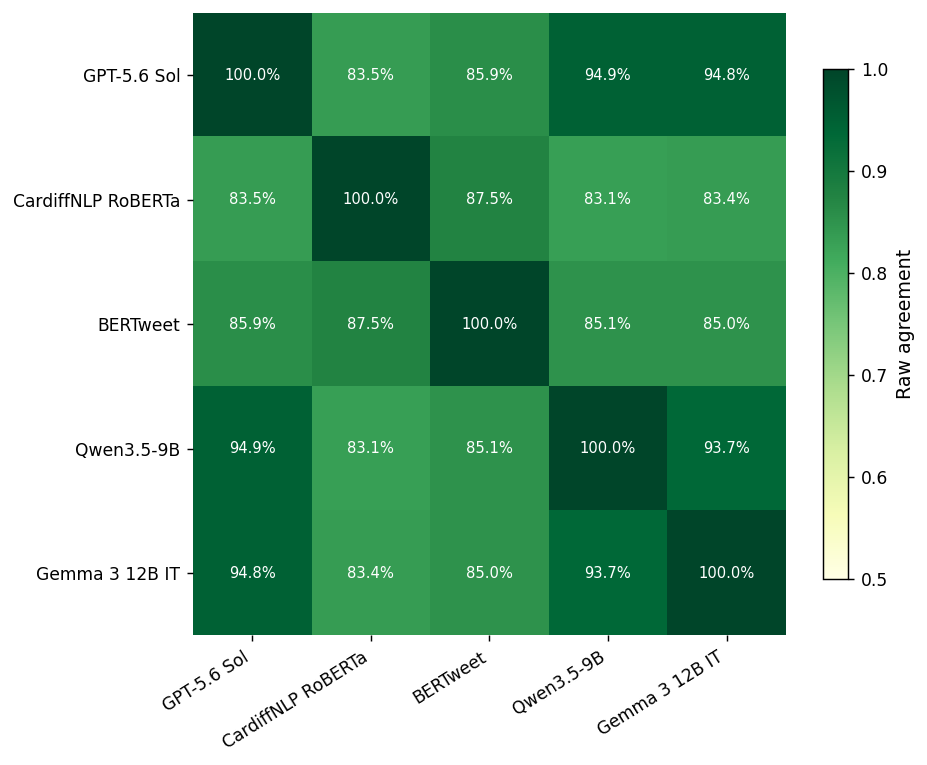

In [25]:
agreement_matrix = pd.DataFrame(
    np.eye(len(MODEL_COLUMNS)),
    index=MODEL_COLUMNS,
    columns=MODEL_COLUMNS,
)

for m1 in MODEL_COLUMNS:
    for m2 in MODEL_COLUMNS:
        agreement_matrix.loc[m1, m2] = (
            model_matrix[m1] == model_matrix[m2]
        ).mean()

fig, ax = plt.subplots(figsize=(7.4, 6.0))

annotated_heatmap(
    agreement_matrix,
    ax,
    cmap="YlGn",
    fmt=".1%",
    vmin=0.5,
    vmax=1.0,
    cbar_label="Raw agreement",
    text_threshold=0.80,
)

ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(
    ax.get_xticklabels(),
    rotation=32,
    ha="right",
)

fig.tight_layout()
save_figure(fig, "fig15_pairwise_model_raw_agreement")
plt.show()
plt.close(fig)

agreement_matrix.to_csv(
    TABLE_DIR / "pairwise_model_raw_agreement.csv",
    encoding="utf-8-sig",
)


## 25. Three-star sentiment heterogeneity across models — Figure 16


Saved: clinic_mixed_methods_outputs\figures\fig16_three_star_sentiment_across_models.pdf


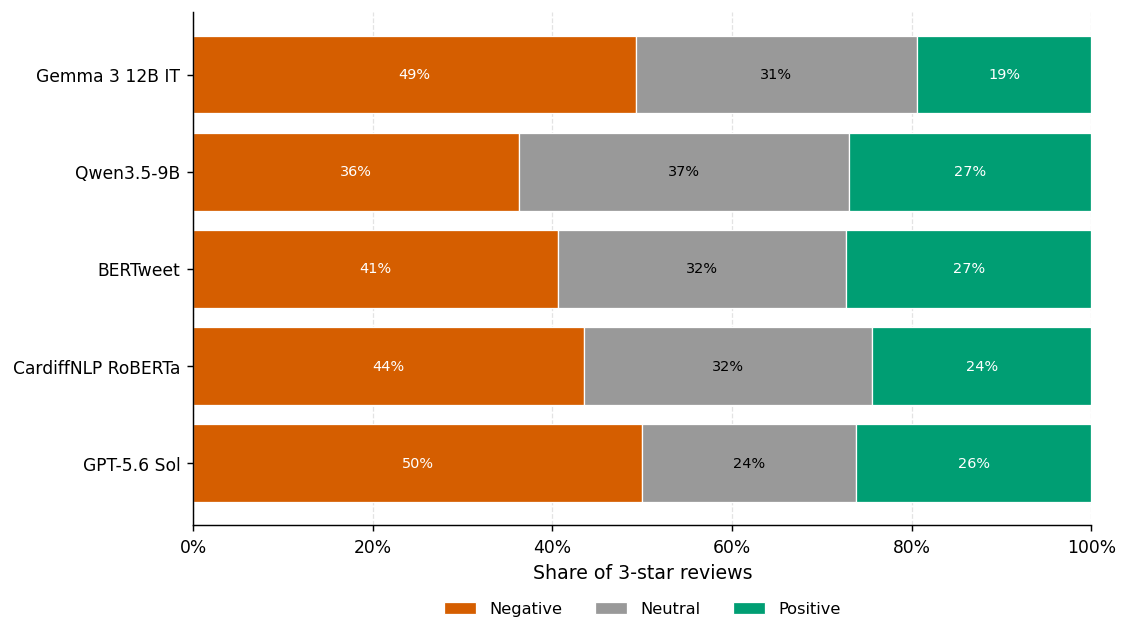

In [26]:
three_star = model_matrix.loc[
    model_matrix["review_rating_num"] == 3
].copy()

three_star_distribution = pd.DataFrame({
    model: (
        three_star[model]
        .value_counts(normalize=True)
        .reindex(LABELS, fill_value=0)
    )
    for model in MODEL_COLUMNS
}).T

fig, ax = plt.subplots(figsize=(8.8, 5.0))

left = np.zeros(len(three_star_distribution))

for label in LABELS:
    vals = three_star_distribution[label].to_numpy(float)

    ax.barh(
        np.arange(len(three_star_distribution)),
        vals,
        left=left,
        color=SENTIMENT_COLORS[label],
        label=label.capitalize(),
        edgecolor="white",
        linewidth=0.7,
    )

    for i, (start, value) in enumerate(zip(left, vals)):
        if value >= 0.08:
            ax.text(
                start + value / 2,
                i,
                f"{value:.0%}",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if label in {"negative", "positive"}
                    else "black"
                ),
            )

    left += vals

ax.set_yticks(np.arange(len(three_star_distribution)))
ax.set_yticklabels(three_star_distribution.index)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Share of 3-star reviews")
ax.set_ylabel("")
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
)
style_axis(ax, "x")

fig.tight_layout()
save_figure(fig, "fig16_three_star_sentiment_across_models")
plt.show()
plt.close(fig)

three_star_distribution.to_csv(
    TABLE_DIR / "three_star_sentiment_across_models.csv",
    encoding="utf-8-sig",
)


## 26. Review-level model-vote entropy by star rating — Figure 17


Saved: clinic_mixed_methods_outputs\figures\fig17_vote_entropy_by_star.pdf


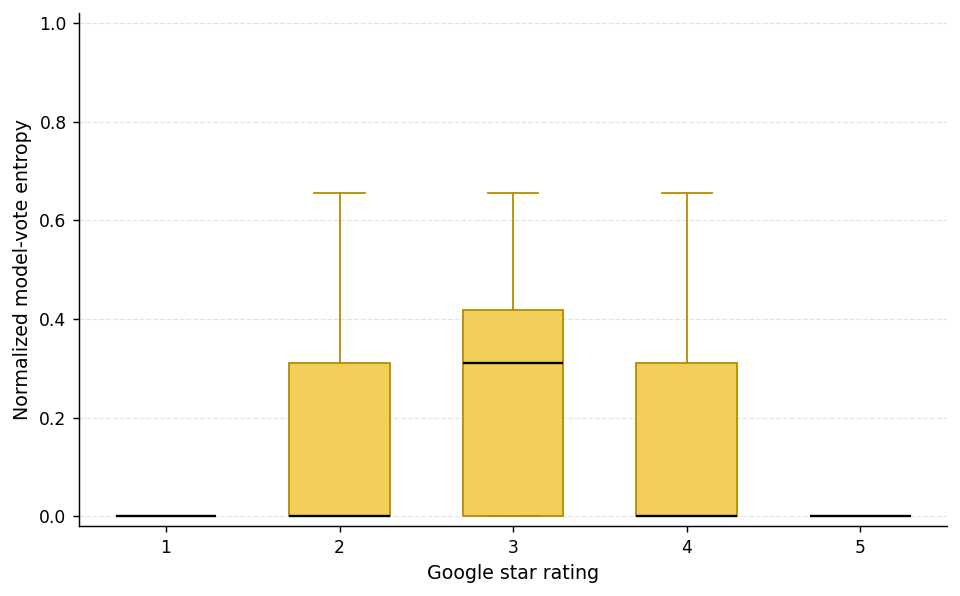

,count,mean,median
review_rating_num,,,
1,1381,0.063,-0.000
2,269,0.142,-0.000
3,278,0.211,0.311
4,453,0.162,-0.000
5,1600,0.069,-0.000


In [27]:
entropy_groups = [
    model_matrix.loc[
        model_matrix["review_rating_num"] == star,
        "vote_entropy_norm",
    ].to_numpy(float)
    for star in [1, 2, 3, 4, 5]
]

fig, ax = plt.subplots(figsize=(7.5, 4.7))

ax.boxplot(
    entropy_groups,
    positions=[1, 2, 3, 4, 5],
    widths=0.58,
    showfliers=False,
    patch_artist=True,
    medianprops={
        "color": "black",
        "linewidth": 1.3,
    },
    boxprops={
        "facecolor": "#F2CF5B",
        "edgecolor": "#B58B00",
    },
    whiskerprops={"color": "#B58B00"},
    capprops={"color": "#B58B00"},
)

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Google star rating")
ax.set_ylabel("Normalized model-vote entropy")
style_axis(ax, "y")

fig.tight_layout()
save_figure(fig, "fig17_vote_entropy_by_star")
plt.show()
plt.close(fig)

entropy_by_star = (
    model_matrix.groupby("review_rating_num")["vote_entropy_norm"]
    .agg(["count", "mean", "median"])
    .reindex([1, 2, 3, 4, 5])
)

entropy_by_star.to_csv(
    TABLE_DIR / "vote_entropy_by_star.csv",
    encoding="utf-8-sig",
)

display(entropy_by_star.round(3))


## 27. Five-model consensus sentiment by star rating — Figure 18


Saved: clinic_mixed_methods_outputs\figures\fig18_consensus_sentiment_by_star.pdf


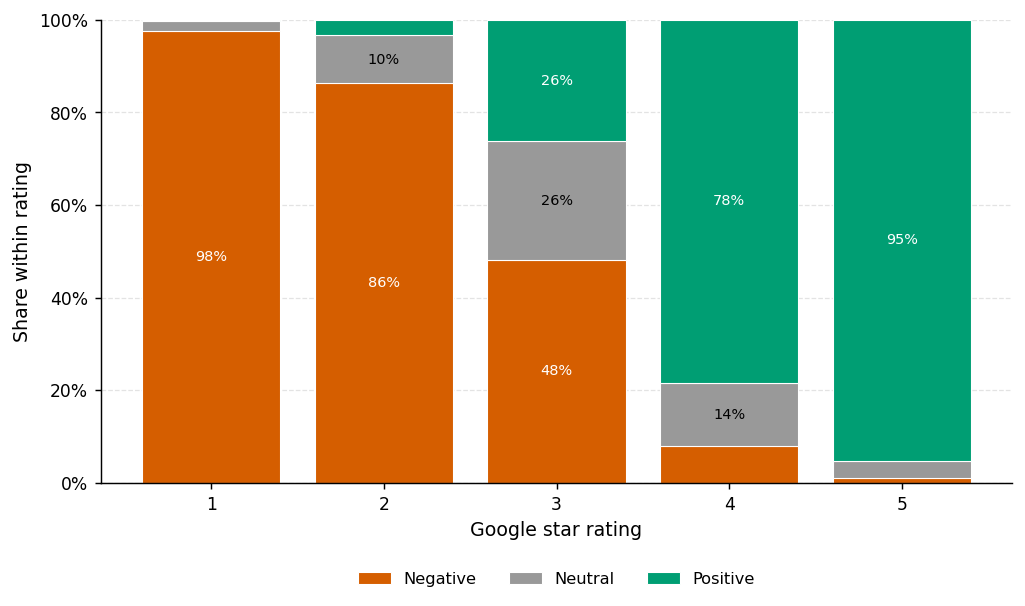

In [28]:
consensus_by_star = (
    pd.crosstab(
        model_matrix["review_rating_num"],
        model_matrix["consensus_sentiment"],
        normalize="index",
    )
    .reindex(
        index=[1, 2, 3, 4, 5],
        columns=LABELS,
        fill_value=0,
    )
)

fig, ax = plt.subplots(figsize=(8.0, 4.8))

draw_100pct_stacked(
    consensus_by_star,
    ax,
    xlabel="Google star rating",
)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
)

fig.tight_layout()
save_figure(fig, "fig18_consensus_sentiment_by_star")
plt.show()
plt.close(fig)

consensus_by_star.to_csv(
    TABLE_DIR / "consensus_sentiment_by_star.csv",
    encoding="utf-8-sig",
)


## 28. Share of non-unanimous decisions by star rating — Figure 19


Saved: clinic_mixed_methods_outputs\figures\fig19_nonunanimous_share_by_star.pdf


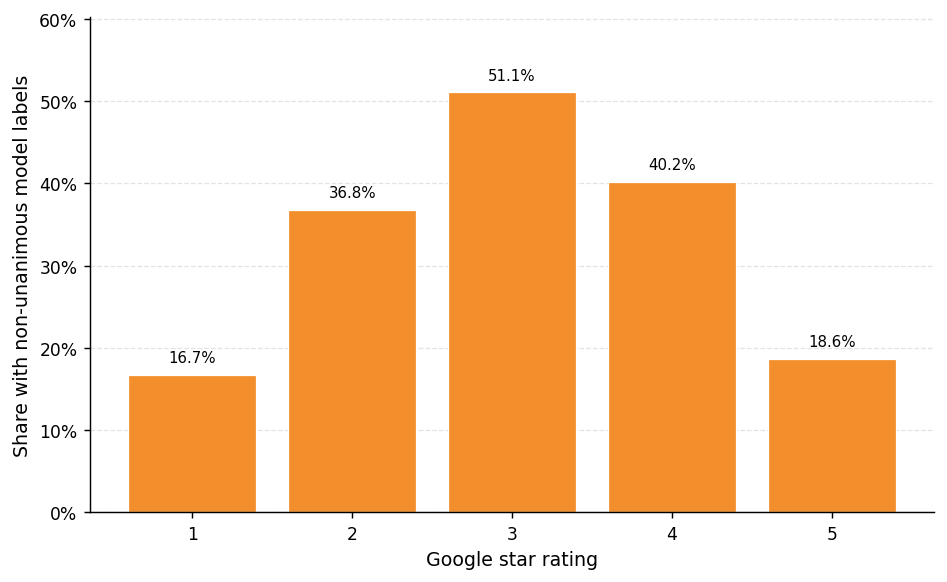

In [29]:
nonunanimous_by_star = (
    model_matrix.assign(
        nonunanimous=~model_matrix["unanimous"]
    )
    .groupby("review_rating_num")
    .agg(
        n=("review_id", "size"),
        nonunanimous_share=("nonunanimous", "mean"),
        mean_distinct_labels=("n_distinct_labels", "mean"),
    )
    .reindex([1, 2, 3, 4, 5])
)

fig, ax = plt.subplots(figsize=(7.4, 4.6))

bars = ax.bar(
    nonunanimous_by_star.index,
    nonunanimous_by_star["nonunanimous_share"],
    color="#F28E2B",
    edgecolor="white",
)

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(
    0,
    max(
        0.05,
        nonunanimous_by_star[
            "nonunanimous_share"
        ].max() * 1.18,
    ),
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Google star rating")
ax.set_ylabel("Share with non-unanimous model labels")
style_axis(ax, "y")

max_share = nonunanimous_by_star[
    "nonunanimous_share"
].max()

for bar, value in zip(
    bars,
    nonunanimous_by_star["nonunanimous_share"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max_share * 0.03,
        f"{value:.1%}",
        ha="center",
        fontsize=8.3,
    )

fig.tight_layout()
save_figure(fig, "fig19_nonunanimous_share_by_star")
plt.show()
plt.close(fig)

nonunanimous_by_star.to_csv(
    TABLE_DIR / "nonunanimous_share_by_star.csv",
    encoding="utf-8-sig",
)


## 29. Mean sentiment index as a model × star heatmap — Figure 20


Saved: clinic_mixed_methods_outputs\figures\fig20_model_star_mean_sentiment_heatmap.pdf


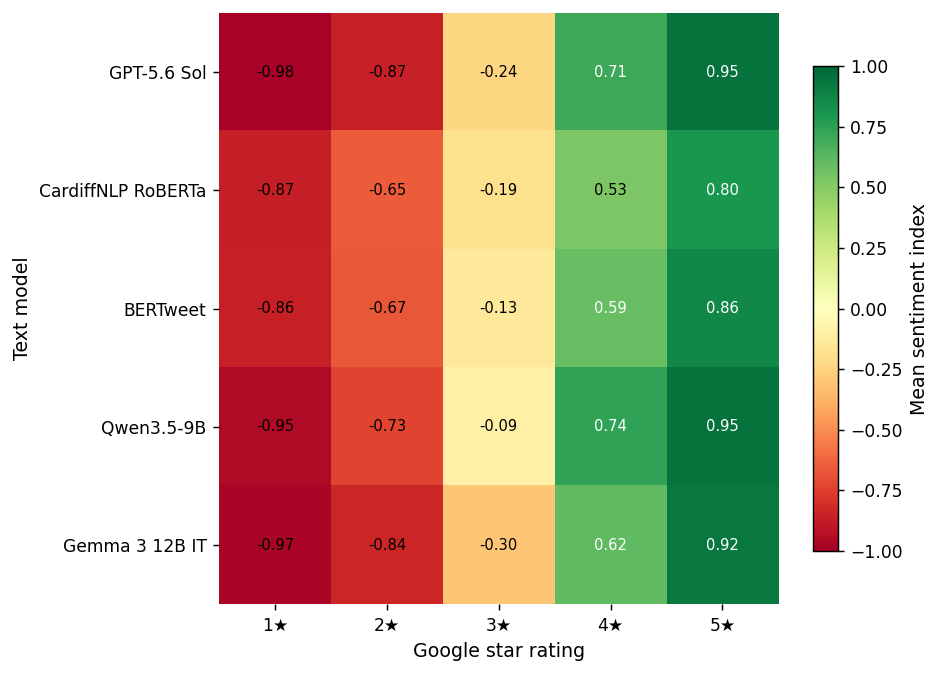

In [30]:
model_star_index = pd.DataFrame({
    model: (
        model_matrix.assign(
            sentiment_index=model_matrix[model].map(INDEX_MAP)
        )
        .groupby("review_rating_num")["sentiment_index"]
        .mean()
        .reindex([1, 2, 3, 4, 5])
    )
    for model in MODEL_COLUMNS
}).T

model_star_index.columns = [
    f"{int(x)}★"
    for x in model_star_index.columns
]

fig, ax = plt.subplots(figsize=(7.3, 5.3))

annotated_heatmap(
    model_star_index,
    ax,
    cmap="RdYlGn",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cbar_label="Mean sentiment index",
    text_threshold=0.55,
)

ax.set_xlabel("Google star rating")
ax.set_ylabel("Text model")

fig.tight_layout()
save_figure(fig, "fig20_model_star_mean_sentiment_heatmap")
plt.show()
plt.close(fig)

model_star_index.to_csv(
    TABLE_DIR / "model_star_mean_sentiment_index.csv",
    encoding="utf-8-sig",
)


## 30. Review length by GPT textual sentiment — Figure 21


Saved: clinic_mixed_methods_outputs\figures\fig21_review_length_by_gpt_sentiment.pdf


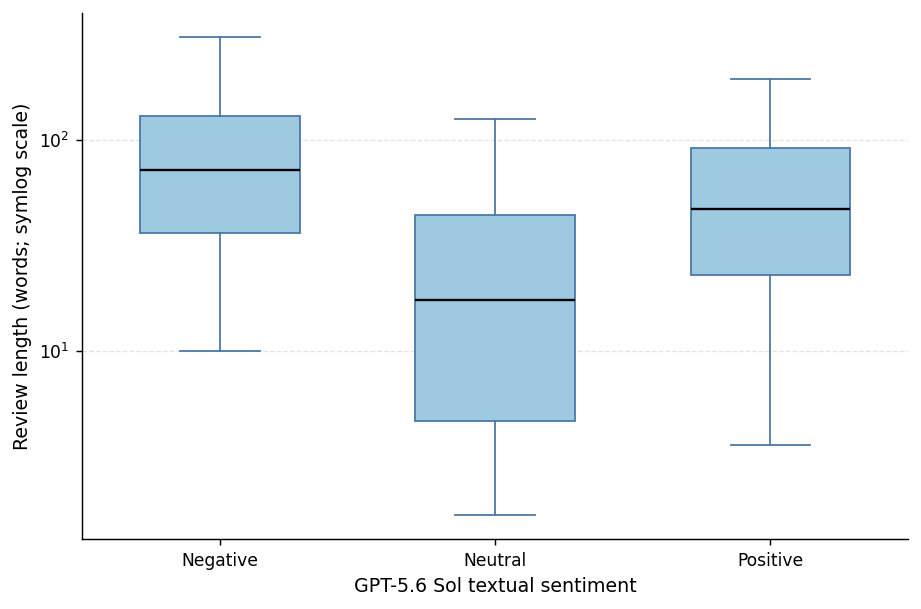

In [31]:
length_by_sentiment = [
    text_df.loc[
        text_df["gpt_norm"] == label,
        "word_count",
    ].to_numpy()
    for label in LABELS
]

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.boxplot(
    length_by_sentiment,
    positions=[1, 2, 3],
    widths=0.58,
    whis=(5, 95),
    showfliers=False,
    patch_artist=True,
    medianprops={
        "color": "black",
        "linewidth": 1.3,
    },
    boxprops={
        "facecolor": "#9ECAE1",
        "edgecolor": "#4C78A8",
    },
    whiskerprops={"color": "#4C78A8"},
    capprops={"color": "#4C78A8"},
)

ax.set_yscale("symlog", linthresh=10)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(
    [x.capitalize() for x in LABELS]
)
ax.set_xlabel("GPT-5.6 Sol textual sentiment")
ax.set_ylabel("Review length (words; symlog scale)")
style_axis(ax, "y")

fig.tight_layout()
save_figure(fig, "fig21_review_length_by_gpt_sentiment")
plt.show()
plt.close(fig)

review_length_by_sentiment = (
    text_df.groupby("gpt_norm")["word_count"]
    .agg(
        n="size",
        median="median",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        mean="mean",
    )
    .reindex(LABELS)
)

review_length_by_sentiment.to_csv(
    TABLE_DIR / "review_length_by_gpt_sentiment.csv",
    encoding="utf-8-sig",
)


## 31. Clinic-level five-model consensus heterogeneity — Figure 22


Saved: clinic_mixed_methods_outputs\figures\fig22_clinic_consensus_rating_text_heterogeneity.pdf


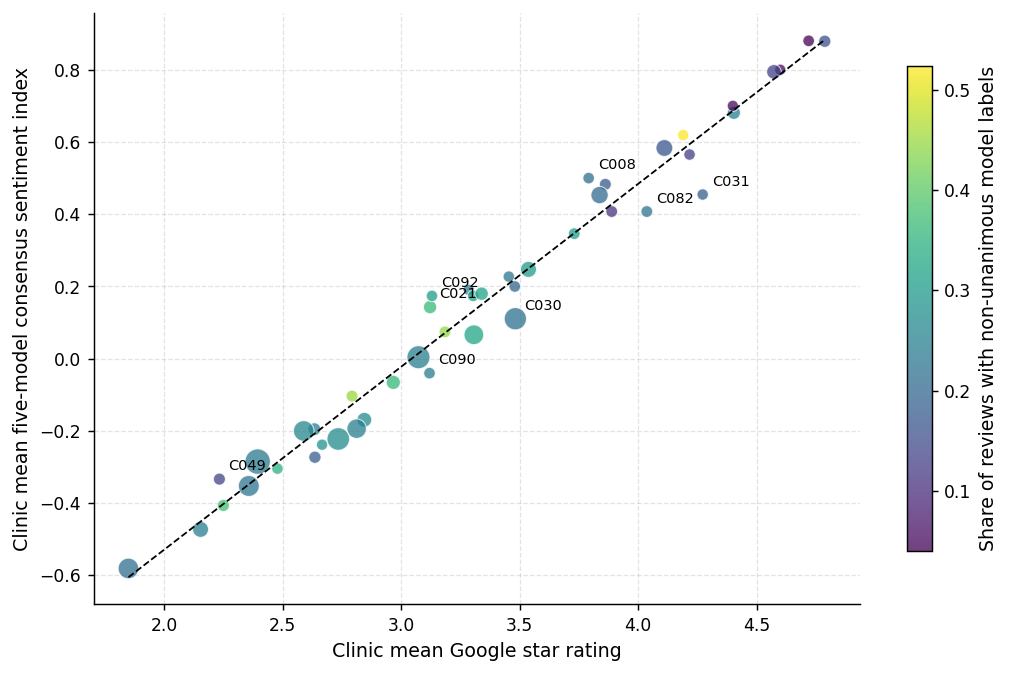

In [32]:
clinic_consensus = (
    model_matrix.assign(
        nonunanimous=~model_matrix["unanimous"],
    )
    .groupby("clinic")
    .agg(
        n=("review_id", "size"),
        mean_star=("review_rating_num", "mean"),
        mean_consensus_index=("consensus_index", "mean"),
        nonunanimous_share=("nonunanimous", "mean"),
        mean_vote_entropy=("vote_entropy_norm", "mean"),
    )
    .reset_index()
)

clinic_consensus["clinic_code"] = (
    clinic_consensus["clinic"].map(clinic_code_map)
)

eligible_consensus = clinic_consensus.loc[
    clinic_consensus["n"] >= MIN_CLINIC_TEXT_REVIEWS
].copy()

coef_consensus = np.polyfit(
    eligible_consensus["mean_star"],
    eligible_consensus["mean_consensus_index"],
    deg=1,
)

eligible_consensus["expected_consensus_index"] = np.polyval(
    coef_consensus,
    eligible_consensus["mean_star"],
)

eligible_consensus["consensus_rating_text_residual"] = (
    eligible_consensus["mean_consensus_index"]
    - eligible_consensus["expected_consensus_index"]
)

sizes = 28 + 170 * (
    eligible_consensus["n"]
    / eligible_consensus["n"].max()
)

fig, ax = plt.subplots(figsize=(8.3, 5.3))

sc = ax.scatter(
    eligible_consensus["mean_star"],
    eligible_consensus["mean_consensus_index"],
    s=sizes,
    c=eligible_consensus["nonunanimous_share"],
    cmap="viridis",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
)

xline = np.linspace(
    eligible_consensus["mean_star"].min(),
    eligible_consensus["mean_star"].max(),
    100,
)

ax.plot(
    xline,
    np.polyval(coef_consensus, xline),
    color="black",
    linestyle="--",
    linewidth=1,
)

label_consensus_df = (
    eligible_consensus.assign(
        abs_residual=eligible_consensus[
            "consensus_rating_text_residual"
        ].abs()
    )
    .nlargest(8, "abs_residual")
)

for _, row in label_consensus_df.iterrows():
    ax.annotate(
        row["clinic_code"],
        (
            row["mean_star"],
            row["mean_consensus_index"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

cbar = fig.colorbar(sc, ax=ax, shrink=0.82)
cbar.set_label(
    "Share of reviews with non-unanimous model labels"
)

ax.set_xlabel("Clinic mean Google star rating")
ax.set_ylabel(
    "Clinic mean five-model consensus sentiment index"
)
style_axis(ax, "both")

fig.tight_layout()
save_figure(
    fig,
    "fig22_clinic_consensus_rating_text_heterogeneity",
)
plt.show()
plt.close(fig)

eligible_consensus.to_csv(
    TABLE_DIR / "clinic_consensus_rating_text_profiles.csv",
    index=False,
    encoding="utf-8-sig",
)


## 32. Largest clinic-level consensus residuals — Figure 23


Saved: clinic_mixed_methods_outputs\figures\fig23_clinic_consensus_residual_lollipop.pdf


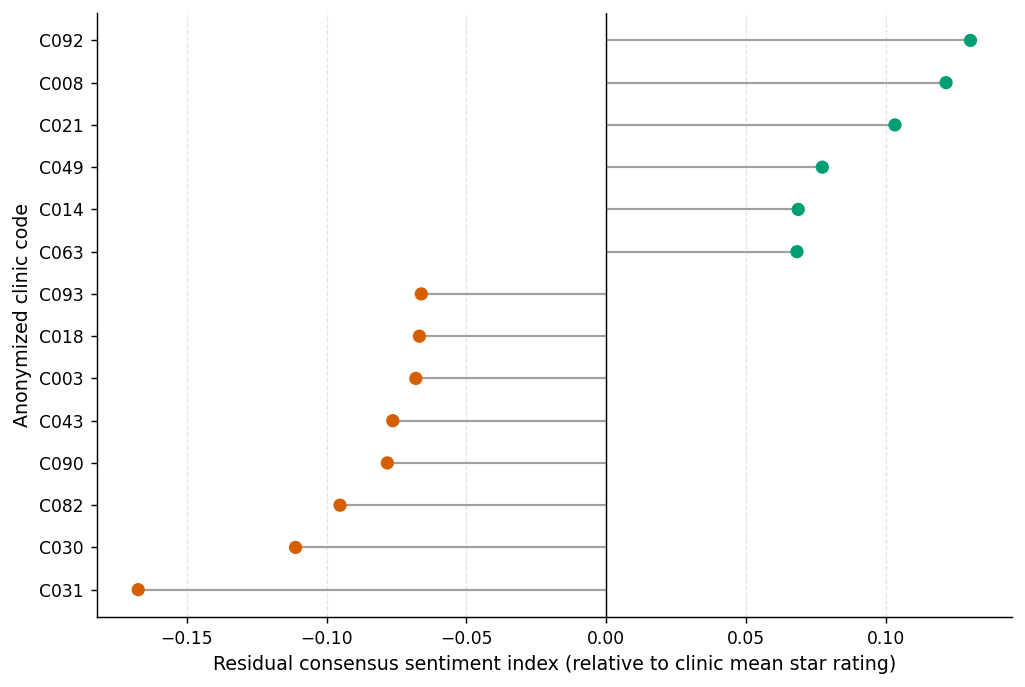

In [33]:
residual_plot = eligible_consensus.copy()

residual_plot["abs_residual"] = (
    residual_plot["consensus_rating_text_residual"].abs()
)

residual_plot = (
    residual_plot
    .nlargest(14, "abs_residual")
    .sort_values("consensus_rating_text_residual")
)

fig, ax = plt.subplots(figsize=(8.0, 5.4))

y = np.arange(len(residual_plot))
values = residual_plot[
    "consensus_rating_text_residual"
].to_numpy(float)

ax.hlines(
    y,
    0,
    values,
    color="#A0A0A0",
    linewidth=1.2,
)

point_colors = [
    SENTIMENT_COLORS["positive"]
    if v >= 0
    else SENTIMENT_COLORS["negative"]
    for v in values
]

ax.scatter(
    values,
    y,
    c=point_colors,
    s=44,
    zorder=3,
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_yticks(y)
ax.set_yticklabels(
    residual_plot["clinic_code"]
)
ax.set_xlabel(
    "Residual consensus sentiment index "
    "(relative to clinic mean star rating)"
)
ax.set_ylabel("Anonymized clinic code")
style_axis(ax, "x")

fig.tight_layout()
save_figure(
    fig,
    "fig23_clinic_consensus_residual_lollipop",
)
plt.show()
plt.close(fig)


## 33. Clinic-level model ambiguity versus review volume — Figure 24


Saved: clinic_mixed_methods_outputs\figures\fig24_clinic_model_ambiguity_vs_volume.pdf


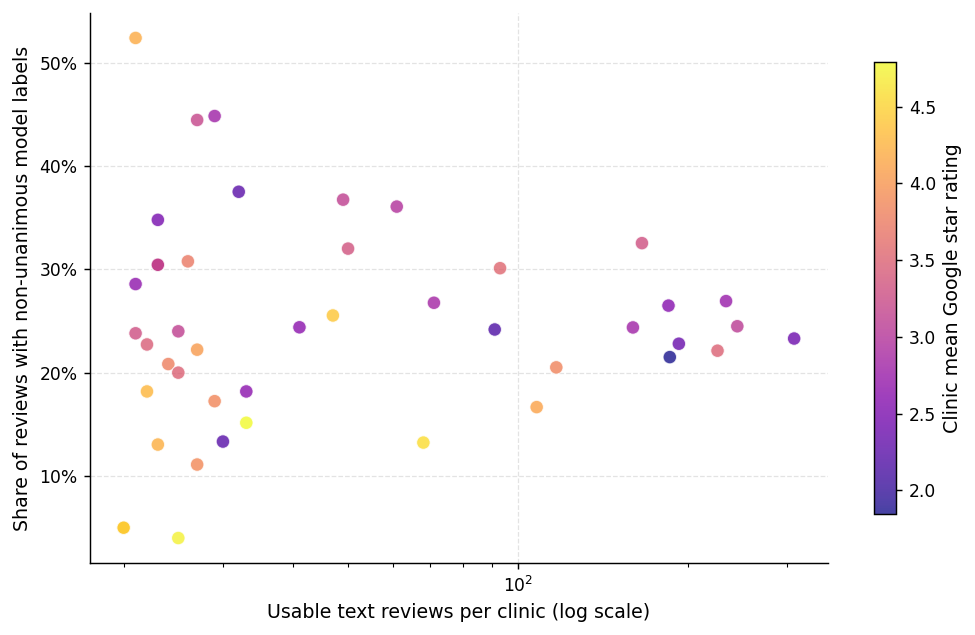

In [34]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))

sc = ax.scatter(
    eligible_consensus["n"],
    eligible_consensus["nonunanimous_share"],
    c=eligible_consensus["mean_star"],
    cmap="plasma",
    s=56,
    alpha=0.76,
    edgecolor="white",
    linewidth=0.6,
)

ax.set_xscale("log")
ax.set_xlabel(
    "Usable text reviews per clinic (log scale)"
)
ax.set_ylabel(
    "Share of reviews with non-unanimous model labels"
)
ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)
style_axis(ax, "both")

cbar = fig.colorbar(sc, ax=ax, shrink=0.82)
cbar.set_label(
    "Clinic mean Google star rating"
)

fig.tight_layout()
save_figure(
    fig,
    "fig24_clinic_model_ambiguity_vs_volume",
)
plt.show()
plt.close(fig)


## 34. Optional MAXQDA theme × GPT sentiment heatmap — Figure 25


In [35]:
if maxqda_available:
    coded_review_ids = (
        codes[["review_id"]]
        .drop_duplicates()
    )

    coded_review_sentiment = (
        coded_review_ids
        .merge(
            text_df[
                ["review_id", "gpt_norm"]
            ],
            on="review_id",
            how="left",
            validate="one_to_one",
        )
    )

    sentiment_denominator = (
        coded_review_sentiment
        .groupby("gpt_norm")["review_id"]
        .nunique()
        .reindex(LABELS)
    )

    code_sentiment_counts = (
        code_review
        .groupby(["code", "gpt_norm"])["review_id"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=LABELS, fill_value=0)
    )

    code_sentiment_prev = (
        code_sentiment_counts.div(
            sentiment_denominator,
            axis=1,
        )
    )

    top_codes_sentiment = (
        code_review.groupby("code")["review_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(18)
        .index
    )

    heat_theme_sentiment = (
        code_sentiment_prev
        .loc[top_codes_sentiment]
        .copy()
    )

    heat_theme_sentiment.columns = [
        x.capitalize()
        for x in heat_theme_sentiment.columns
    ]

    fig, ax = plt.subplots(
        figsize=(
            7.5,
            max(
                5.6,
                0.36 * len(heat_theme_sentiment) + 1.4,
            ),
        )
    )

    annotated_heatmap(
        heat_theme_sentiment,
        ax,
        cmap="PuBuGn",
        fmt=".0%",
        vmin=0,
        vmax=max(
            0.01,
            float(
                np.nanmax(
                    heat_theme_sentiment.to_numpy(float)
                )
            ),
        ),
        cbar_label=(
            "Theme prevalence within GPT sentiment group"
        ),
    )

    ax.set_xlabel(
        "GPT-5.6 Sol textual sentiment"
    )
    ax.set_ylabel("MAXQDA theme")

    fig.tight_layout()
    save_figure(
        fig,
        "fig25_maxqda_theme_prevalence_by_gpt_sentiment",
    )
    plt.show()
    plt.close(fig)

    code_sentiment_prev.to_csv(
        TABLE_DIR
        / "maxqda_theme_prevalence_by_gpt_sentiment.csv",
        encoding="utf-8-sig",
    )
else:
    print(
        "Figure 25 skipped until maxqda_review_codes.csv "
        "is available."
    )


Figure 25 skipped until maxqda_review_codes.csv is available.


## 35. Optional MAXQDA top-theme frequency profile — Figure 26


In [36]:
if maxqda_available:
    top_theme_counts = (
        code_review.groupby("code")["review_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(20)
        .sort_values()
    )

    fig, ax = plt.subplots(
        figsize=(
            8.2,
            max(5.3, 0.30 * len(top_theme_counts) + 1.4),
        )
    )

    bars = ax.barh(
        top_theme_counts.index,
        top_theme_counts.values,
        color="#59A14F",
        edgecolor="white",
    )

    ax.set_xlabel("Number of coded reviews")
    ax.set_ylabel("")
    style_axis(ax, "x")

    for bar, value in zip(
        bars,
        top_theme_counts.values,
    ):
        ax.text(
            value
            + max(
                top_theme_counts.max() * 0.012,
                0.5,
            ),
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}",
            va="center",
            fontsize=8,
        )

    ax.set_xlim(
        0,
        top_theme_counts.max() * 1.12,
    )

    fig.tight_layout()
    save_figure(
        fig,
        "fig26_maxqda_top_theme_frequency",
    )
    plt.show()
    plt.close(fig)
else:
    print(
        "Figure 26 skipped until maxqda_review_codes.csv "
        "is available."
    )


Figure 26 skipped until maxqda_review_codes.csv is available.


# Part VII — Defense-oriented summary


In [37]:
figure_files = sorted(FIG_DIR.glob("*.pdf"))
table_files = sorted(TABLE_DIR.glob("*"))
case_files = sorted(CASE_DIR.glob("*"))

print("Kyoto clinic mixed-methods analysis notebook complete.")
print()
print("Figures generated:", len(figure_files))
print("Tables generated:", len(table_files))
print("Case exports:", len(case_files))
print()
print("Figures:", FIG_DIR.resolve())
print("Tables:", TABLE_DIR.resolve())
print("Case exports:", CASE_DIR.resolve())
print()
print("MAXQDA integration available:", maxqda_available)
print("Server models loaded:", len(server_predictions), "/", len(SERVER_MODEL_FILES))
print("Models in robustness panel:", len(MODEL_COLUMNS))


Kyoto clinic mixed-methods analysis notebook complete.

Figures generated: 23
Tables generated: 24
Case exports: 5

Figures: C:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\MP4-Kaveesha\clinic_mixed_methods_outputs\figures
Tables: C:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\MP4-Kaveesha\clinic_mixed_methods_outputs\tables
Case exports: C:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\MP4-Kaveesha\clinic_mixed_methods_outputs\case_exports

MAXQDA integration available: False
Server models loaded: 4 / 4
Models in robustness panel: 5
